# 06 — Model Evaluation

Comparative evaluation of **GBR** (HistGradientBoostingRegressor) and **CatBoost** across four turbidity datasets and five spatial scales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

try:
    from catboost import CatBoostRegressor
    CATBOOST_OK = True
except ImportError:
    CATBOOST_OK = False

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [2]:
BASE_DIR = Path('..')
RES_DIR  = BASE_DIR / 'results'
MOD_DIR  = RES_DIR / 'models'
PROC_DIR = BASE_DIR / 'data' / 'processed'

MODEL_COLORS = {'GBR': '#2196F3', 'CatBoost': '#E65100'}
DS_COLORS    = {'base': '#4CAF50', 'log1p': '#2196F3', 'trimmed': '#FF9800', 'yeojohnson': '#9C27B0'}
DS_ORDER     = ['base', 'log1p', 'trimmed', 'yeojohnson']
PX_ORDER     = [16, 32, 64, 128, 256]

## 1. Loading results

In [3]:
metrics_df    = pd.read_csv(RES_DIR / 'model_metrics.csv')
test_preds_df = pd.read_csv(RES_DIR / 'test_predictions.csv',  parse_dates=['date'])
oof_preds_df  = pd.read_csv(RES_DIR / 'oof_predictions.csv',   parse_dates=['date'])
base_df       = pd.read_csv(PROC_DIR / 'dataset_base.csv',     parse_dates=['date'])

with open(RES_DIR / 'best_model_info.json') as f:
    best_info = json.load(f)

best_ds    = best_info['best_dataset']
best_px    = best_info['best_patch_px']
best_model = best_info['best_model']

available_models = sorted(metrics_df['model'].unique().tolist())

print(f'Available models: {available_models}')
print(f'Datasets         : {metrics_df["dataset"].unique().tolist()}')
print(f'Patch sizes (px) : {sorted(metrics_df["patch_px"].unique().tolist())}')
print(f'Total combinations: {len(metrics_df)}')
print()
print('Top 10 — test MAE ↓')
top = (metrics_df[['dataset','patch_px','diameter_m','model',
                    'test_mae','test_rmse','test_r2','test_pearson_r',
                    'cv_mae','cv_mae_std','oof_mae']]
       .sort_values('test_mae').head(10).reset_index(drop=True))
print(top.to_string())
print(f'\nBest combo: {best_ds} × {best_px}px × {best_model}  →  MAE={best_info["test_mae"]:.4f} NTU  R²={best_info["test_r2"]:.4f}')

Available models: ['CatBoost', 'GBR']
Datasets         : ['base', 'log1p', 'trimmed', 'yeojohnson']
Patch sizes (px) : [16, 32, 64, 128, 256]
Total combinations: 40

Top 10 — test MAE ↓
  dataset  patch_px  diameter_m     model  test_mae  test_rmse  test_r2  test_pearson_r  cv_mae  cv_mae_std  oof_mae
0   log1p       128         384  CatBoost    0.2531     0.3163  -0.1305          0.0326  0.2793      0.0716   0.2810
1   log1p        16          48  CatBoost    0.2605     0.3490  -0.0742         -0.1589  0.3058      0.0849   0.3031
2   log1p        64         192  CatBoost    0.2614     0.3477  -0.0663         -0.0793  0.3050      0.0843   0.3023
3   log1p        32          96  CatBoost    0.2654     0.3551  -0.1121         -0.1202  0.3056      0.0851   0.3029
4   log1p        16          48       GBR    0.2735     0.3636  -0.1659          0.1186  0.3333      0.0645   0.3315
5   log1p       128         384       GBR    0.2801     0.3404  -0.3091          0.0809  0.3062      0.0480   0.

## 2. Metrics heatmaps: dataset × patch_px (by model)

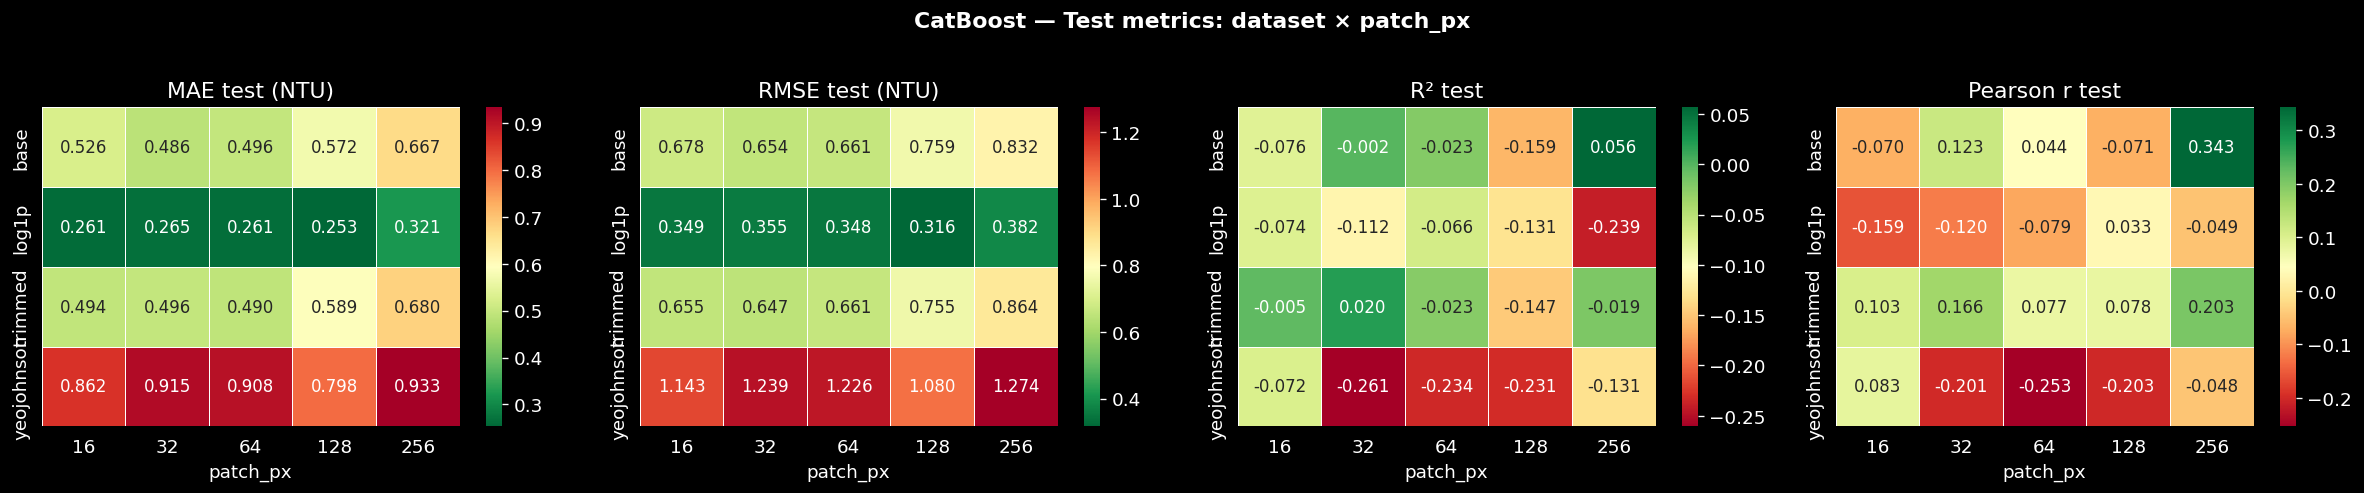

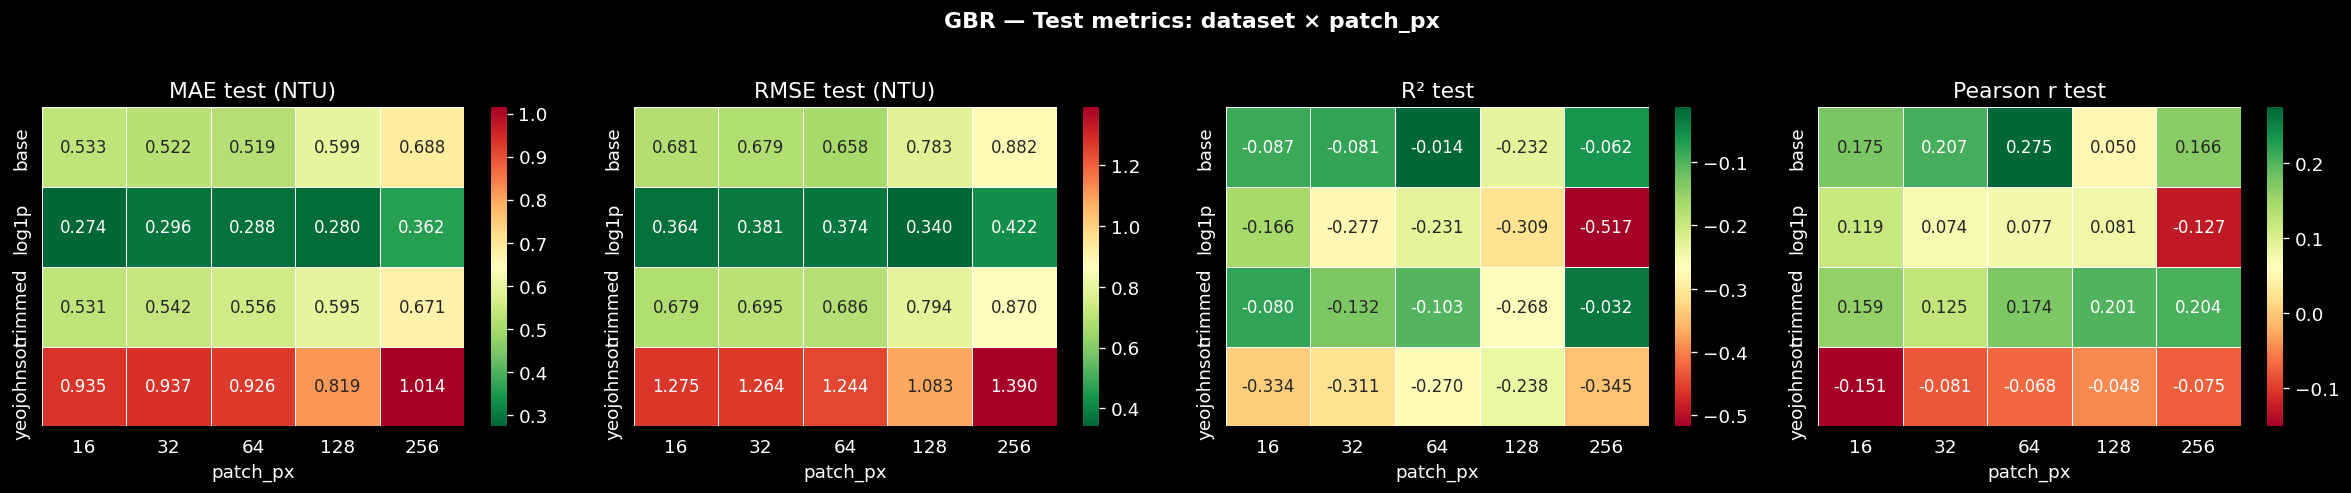

In [4]:
metrics_to_plot = [
    ('test_mae',       'MAE test (NTU)',   'RdYlGn_r', '.3f'),
    ('test_rmse',      'RMSE test (NTU)',  'RdYlGn_r', '.3f'),
    ('test_r2',        'R² test',          'RdYlGn',   '.3f'),
    ('test_pearson_r', 'Pearson r test',   'RdYlGn',   '.3f'),
]

for mtype in available_models:
    sub = metrics_df[metrics_df['model'] == mtype].copy()
    sub['patch_px'] = sub['patch_px'].astype(int)

    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 4))
    for ax, (metric, label, cmap, fmt) in zip(axes, metrics_to_plot):
        pivot = (sub.pivot_table(index='dataset', columns='patch_px', values=metric)
                   .reindex(index=[d for d in DS_ORDER if d in sub['dataset'].values],
                            columns=[p for p in PX_ORDER if p in sub['patch_px'].values]))
        sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap,
                    ax=ax, linewidths=0.5, annot_kws={'size': 10})
        ax.set_title(label)
        ax.set_xlabel('patch_px')
        ax.set_ylabel('')

    plt.suptitle(f'{mtype} — Test metrics: dataset × patch_px', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RES_DIR / f'eval_heatmap_{mtype}.png', bbox_inches='tight')
    plt.show()
    print()

## 3. Overfitting diagnosis: CV vs OOF vs Test

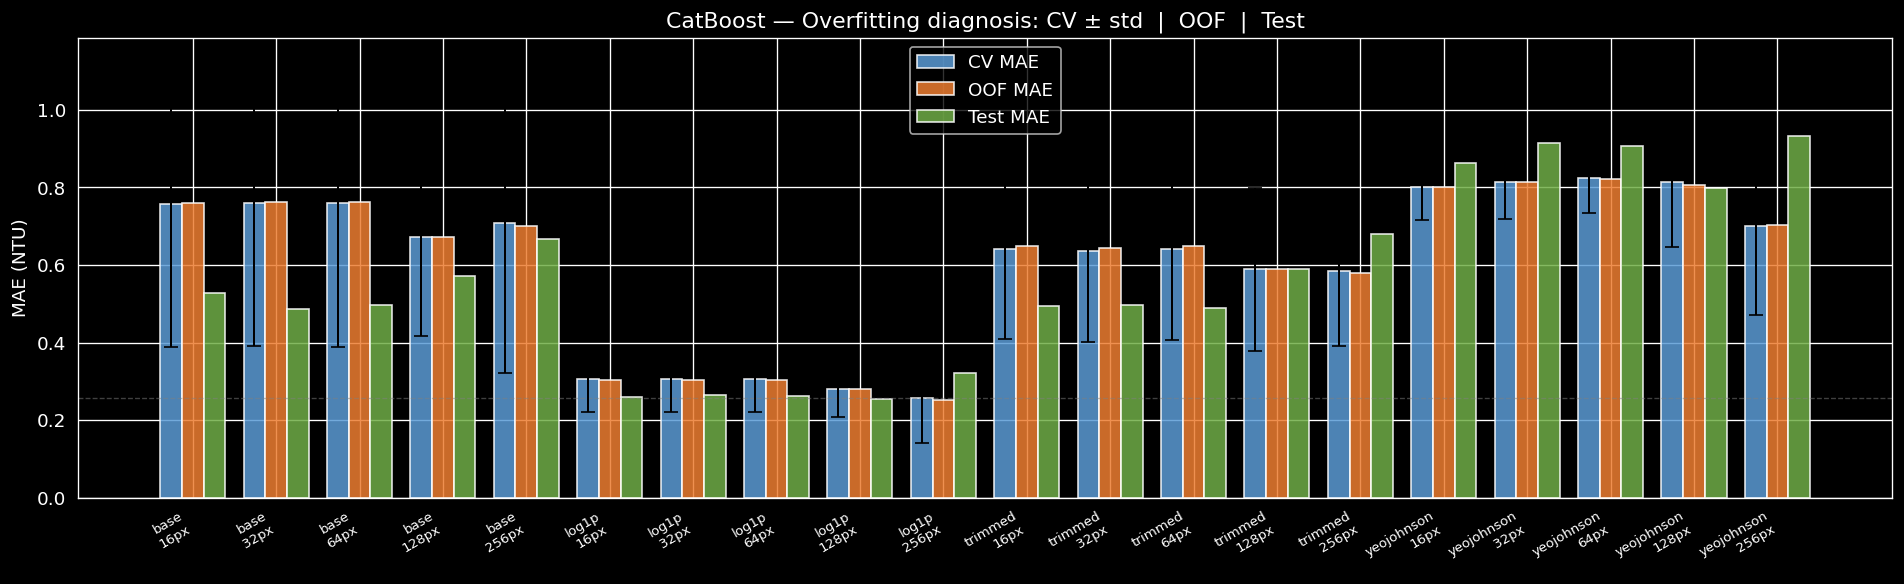

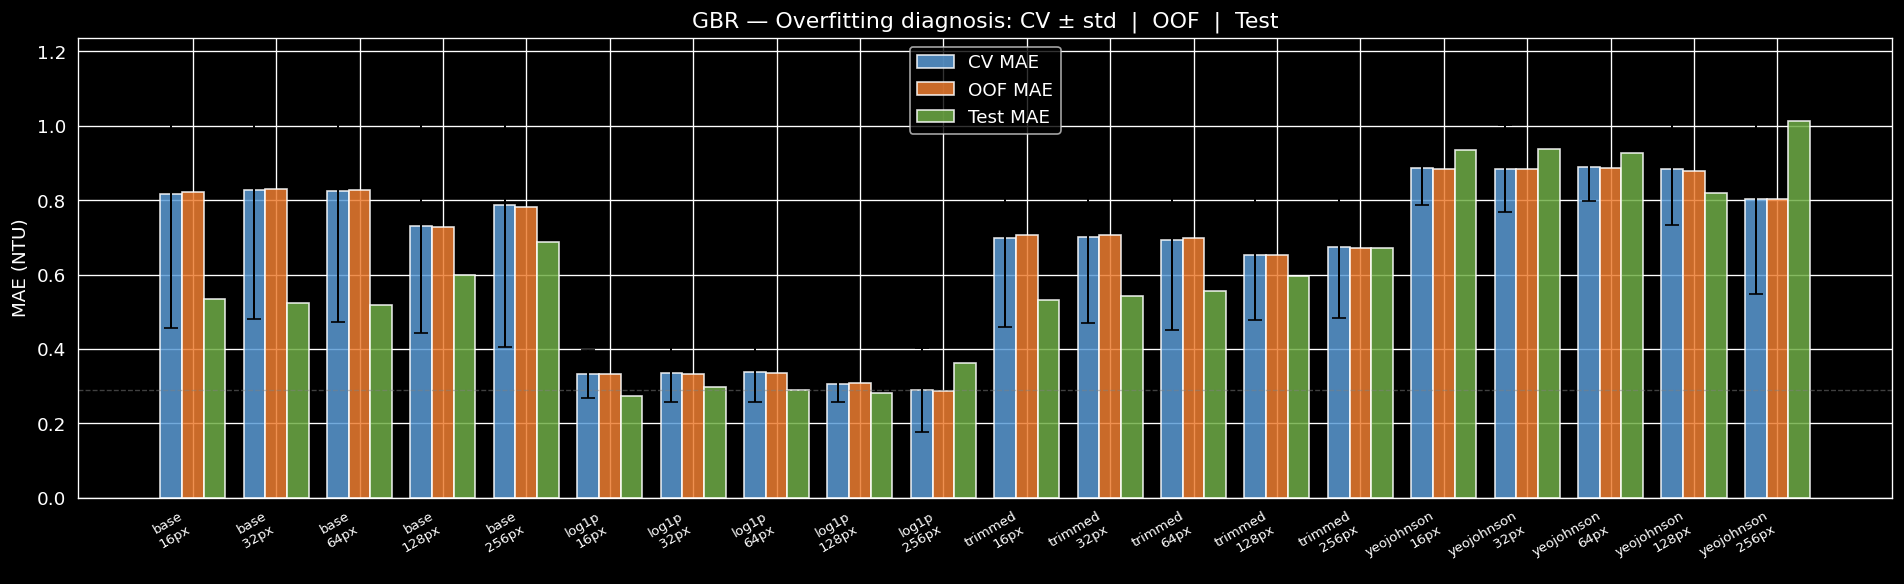

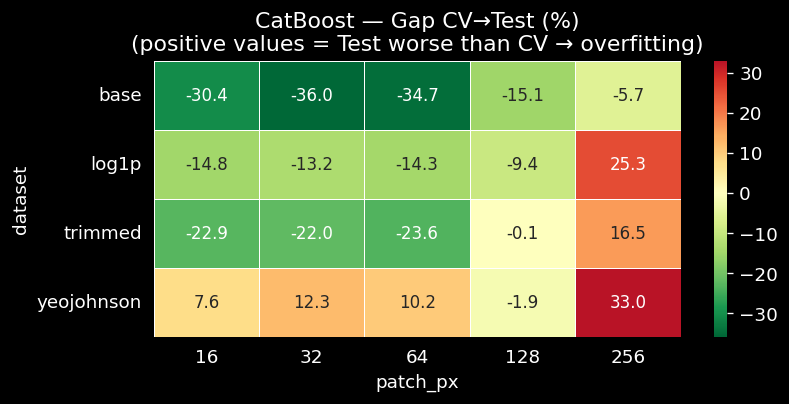

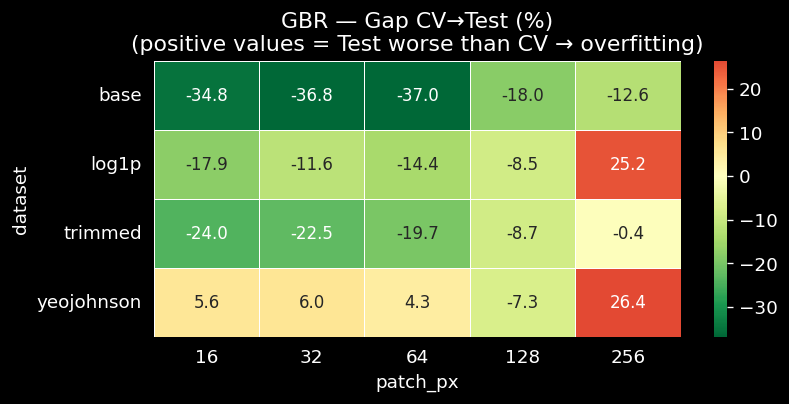

In [5]:
for mtype in available_models:
    sub = (metrics_df[metrics_df['model'] == mtype]
           .sort_values(['dataset', 'patch_px'])
           .reset_index(drop=True))

    labels = [f"{r['dataset']}\n{r['patch_px']}px" for _, r in sub.iterrows()]
    x = np.arange(len(sub))
    w = 0.26

    fig, ax = plt.subplots(figsize=(max(14, len(sub) * 0.8), 5))
    ax.bar(x - w, sub['cv_mae'],   width=w, label='CV MAE',   color='#5B9BD5', alpha=0.85, edgecolor='white')
    ax.bar(x,     sub['oof_mae'],  width=w, label='OOF MAE',  color='#ED7D31', alpha=0.85, edgecolor='white')
    ax.bar(x + w, sub['test_mae'], width=w, label='Test MAE', color='#70AD47', alpha=0.85, edgecolor='white')
    ax.errorbar(x - w, sub['cv_mae'], yerr=sub['cv_mae_std'],
                fmt='none', color='black', capsize=4, linewidth=1.2, zorder=5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('MAE (NTU)')
    ax.set_title(f'{mtype} — Overfitting diagnosis: CV ± std  |  OOF  |  Test')
    ax.legend()
    ax.axhline(sub['cv_mae'].min(), color='gray', lw=0.8, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(RES_DIR / f'eval_overfit_{mtype}.png', bbox_inches='tight')
    plt.show()
    print()

# Relative gap CV → Test
metrics_df['gap_pct'] = ((metrics_df['test_mae'] - metrics_df['cv_mae'])
                          / metrics_df['cv_mae'] * 100).round(1)

for mtype in available_models:
    sub = metrics_df[metrics_df['model'] == mtype].copy()
    sub['patch_px'] = sub['patch_px'].astype(int)
    pivot_gap = (sub.pivot_table(index='dataset', columns='patch_px', values='gap_pct')
                   .reindex(index=[d for d in DS_ORDER if d in sub['dataset'].values],
                            columns=[p for p in PX_ORDER if p in sub['patch_px'].values]))

    fig, ax = plt.subplots(figsize=(7, 3.5))
    sns.heatmap(pivot_gap, annot=True, fmt='.1f', cmap='RdYlGn_r',
                ax=ax, linewidths=0.5, center=0, annot_kws={'size': 10})
    ax.set_title(f'{mtype} — Gap CV→Test (%)\n(positive values = Test worse than CV → overfitting)')
    plt.tight_layout()
    plt.savefig(RES_DIR / f'eval_gap_{mtype}.png', bbox_inches='tight')
    plt.show()
    print()

## 4. Scatter plots: predicted vs actual (best combo per dataset)

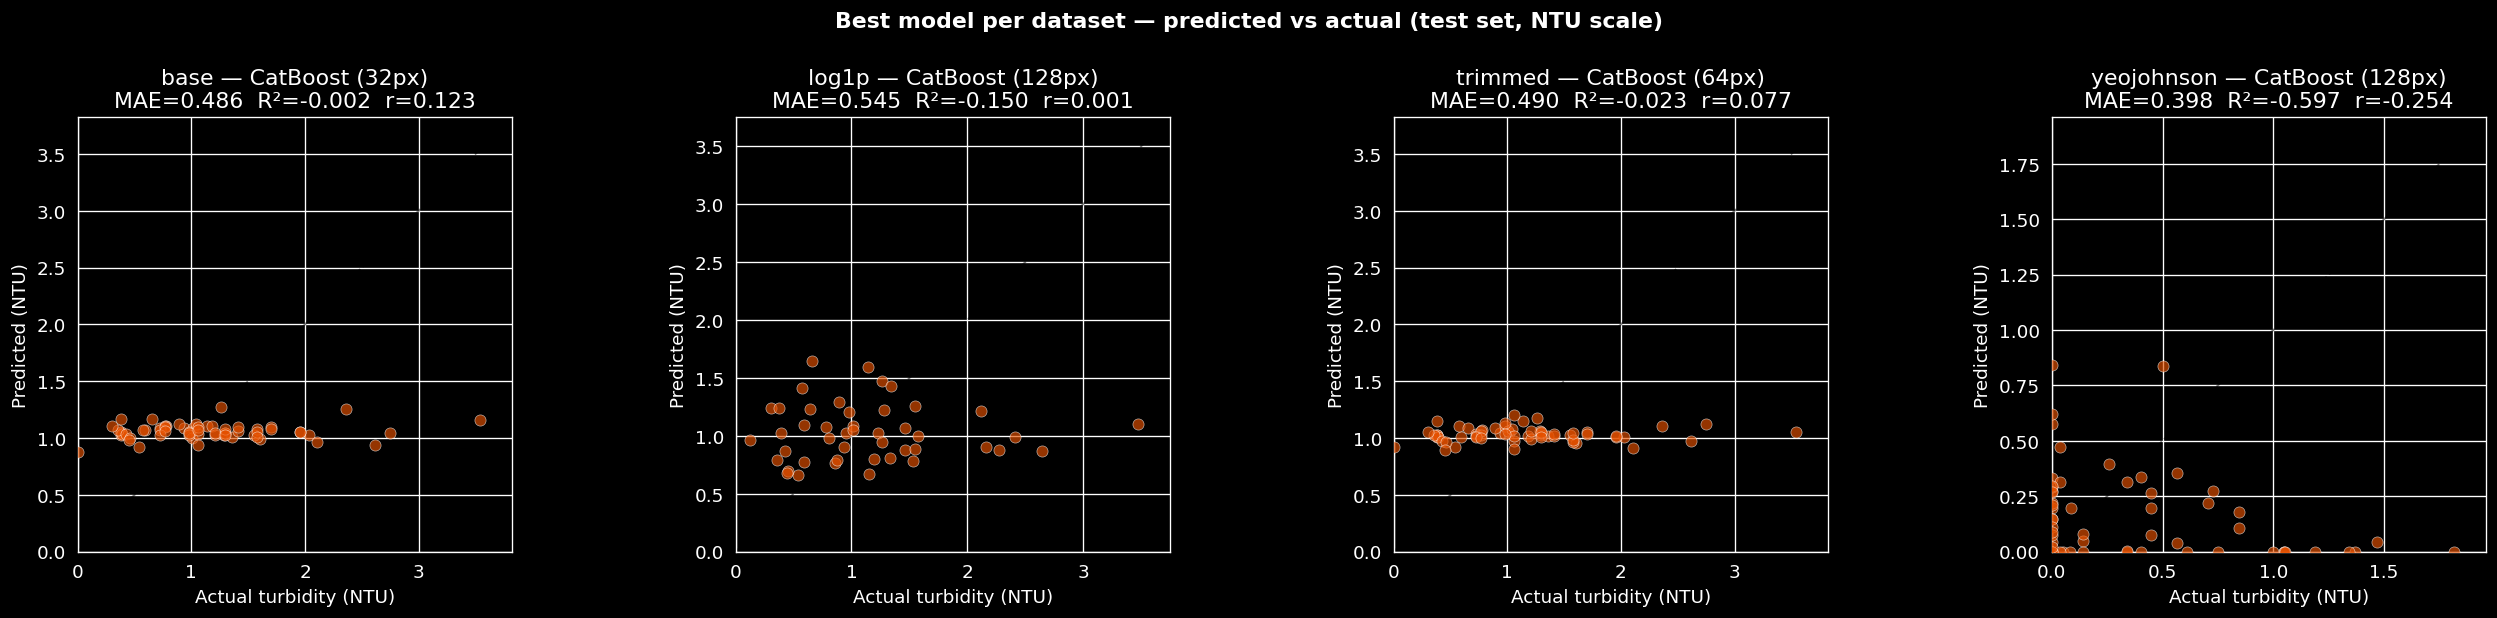

In [10]:
def to_ntu(vals, dataset):
    """Convert predictions to original NTU scale."""
    if dataset == 'log1p':
        return np.expm1(np.maximum(vals, 0))
    return np.maximum(vals, 0)

best_per_ds = (metrics_df.sort_values('test_mae')
               .groupby(['dataset', 'model']).first().reset_index()
               .sort_values('test_mae').groupby('dataset').first().reset_index())

n = len(best_per_ds)
ncols = min(n, 4)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

for ax, (_, row) in zip(axes, best_per_ds.iterrows()):
    ds, mt, px = row['dataset'], row['model'], int(row['patch_px'])
    sub  = test_preds_df[(test_preds_df['dataset'] == ds) &
                          (test_preds_df['patch_px'] == px) &
                          (test_preds_df['model']    == mt)]

    y_t = to_ntu(sub['turbidity'].values, ds)
    y_p = to_ntu(sub['pred'].values,      ds)

    mae  = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2   = r2_score(y_t, y_p)
    pr   = pearsonr(y_t, y_p)[0]

    color = MODEL_COLORS.get(mt, 'steelblue')
    ax.scatter(y_t, y_p, alpha=0.65, s=45, color=color,
               edgecolors='white', linewidth=0.4, zorder=3)
    lim = max(y_t.max(), y_p.max()) * 1.08
    ax.plot([0, lim], [0, lim], 'k--', lw=1.2, alpha=0.5)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Actual turbidity (NTU)')
    ax.set_ylabel('Predicted (NTU)')
    ax.set_title(f'{ds} — {mt} ({px}px)\nMAE={mae:.3f}  R²={r2:.3f}  r={pr:.3f}')
    ax.set_aspect('equal')

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Best model per dataset — predicted vs actual (test set, NTU scale)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RES_DIR / 'eval_scatter_best_per_ds.png', bbox_inches='tight')
plt.show()

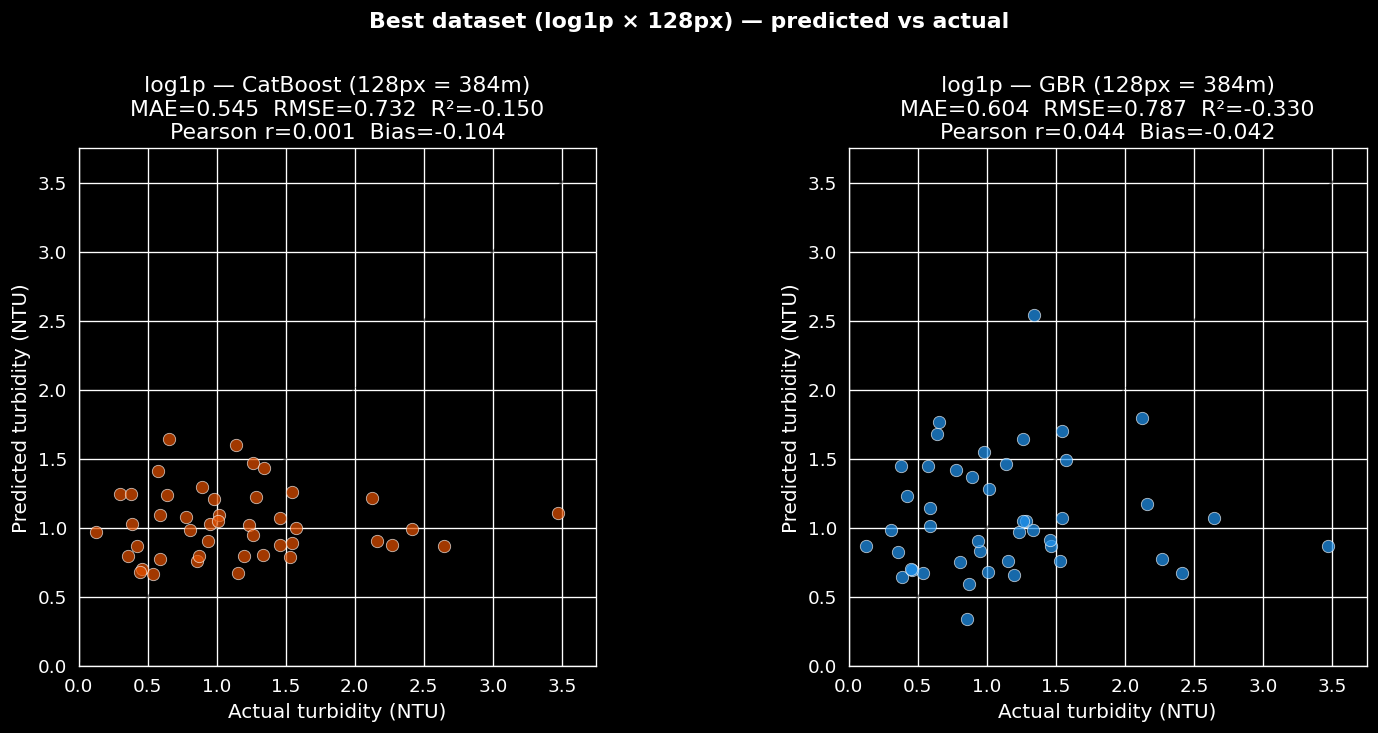

In [11]:
# Scatter for the global best combination — all models
fig, axes = plt.subplots(1, len(available_models), figsize=(6.5 * len(available_models), 6))
if len(available_models) == 1:
    axes = [axes]

for ax, mt in zip(axes, available_models):
    sub  = test_preds_df[(test_preds_df['dataset']  == best_ds) &
                          (test_preds_df['patch_px'] == best_px) &
                          (test_preds_df['model']    == mt)]
    y_t  = to_ntu(sub['turbidity'].values, best_ds)
    y_p  = to_ntu(sub['pred'].values,      best_ds)
    mae  = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2   = r2_score(y_t, y_p)
    pr   = pearsonr(y_t, y_p)[0]
    bias = float(np.mean(y_p - y_t))

    color = MODEL_COLORS.get(mt, 'steelblue')
    ax.scatter(y_t, y_p, alpha=0.70, s=55, color=color,
               edgecolors='white', linewidth=0.5, zorder=3)
    lim = max(y_t.max(), y_p.max()) * 1.08
    ax.plot([0, lim], [0, lim], 'k--', lw=1.2, alpha=0.5)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Actual turbidity (NTU)', fontsize=12)
    ax.set_ylabel('Predicted turbidity (NTU)', fontsize=12)
    ax.set_title(
        f'{best_ds} — {mt} ({best_px}px = {best_px*3}m)\n'
        f'MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}\n'
        f'Pearson r={pr:.3f}  Bias={bias:+.3f}'
    )
    ax.set_aspect('equal')

plt.suptitle(f'Best dataset ({best_ds} × {best_px}px) — predicted vs actual',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RES_DIR / 'eval_scatter_best.png', bbox_inches='tight')
plt.show()

## 5. Residuals analysis

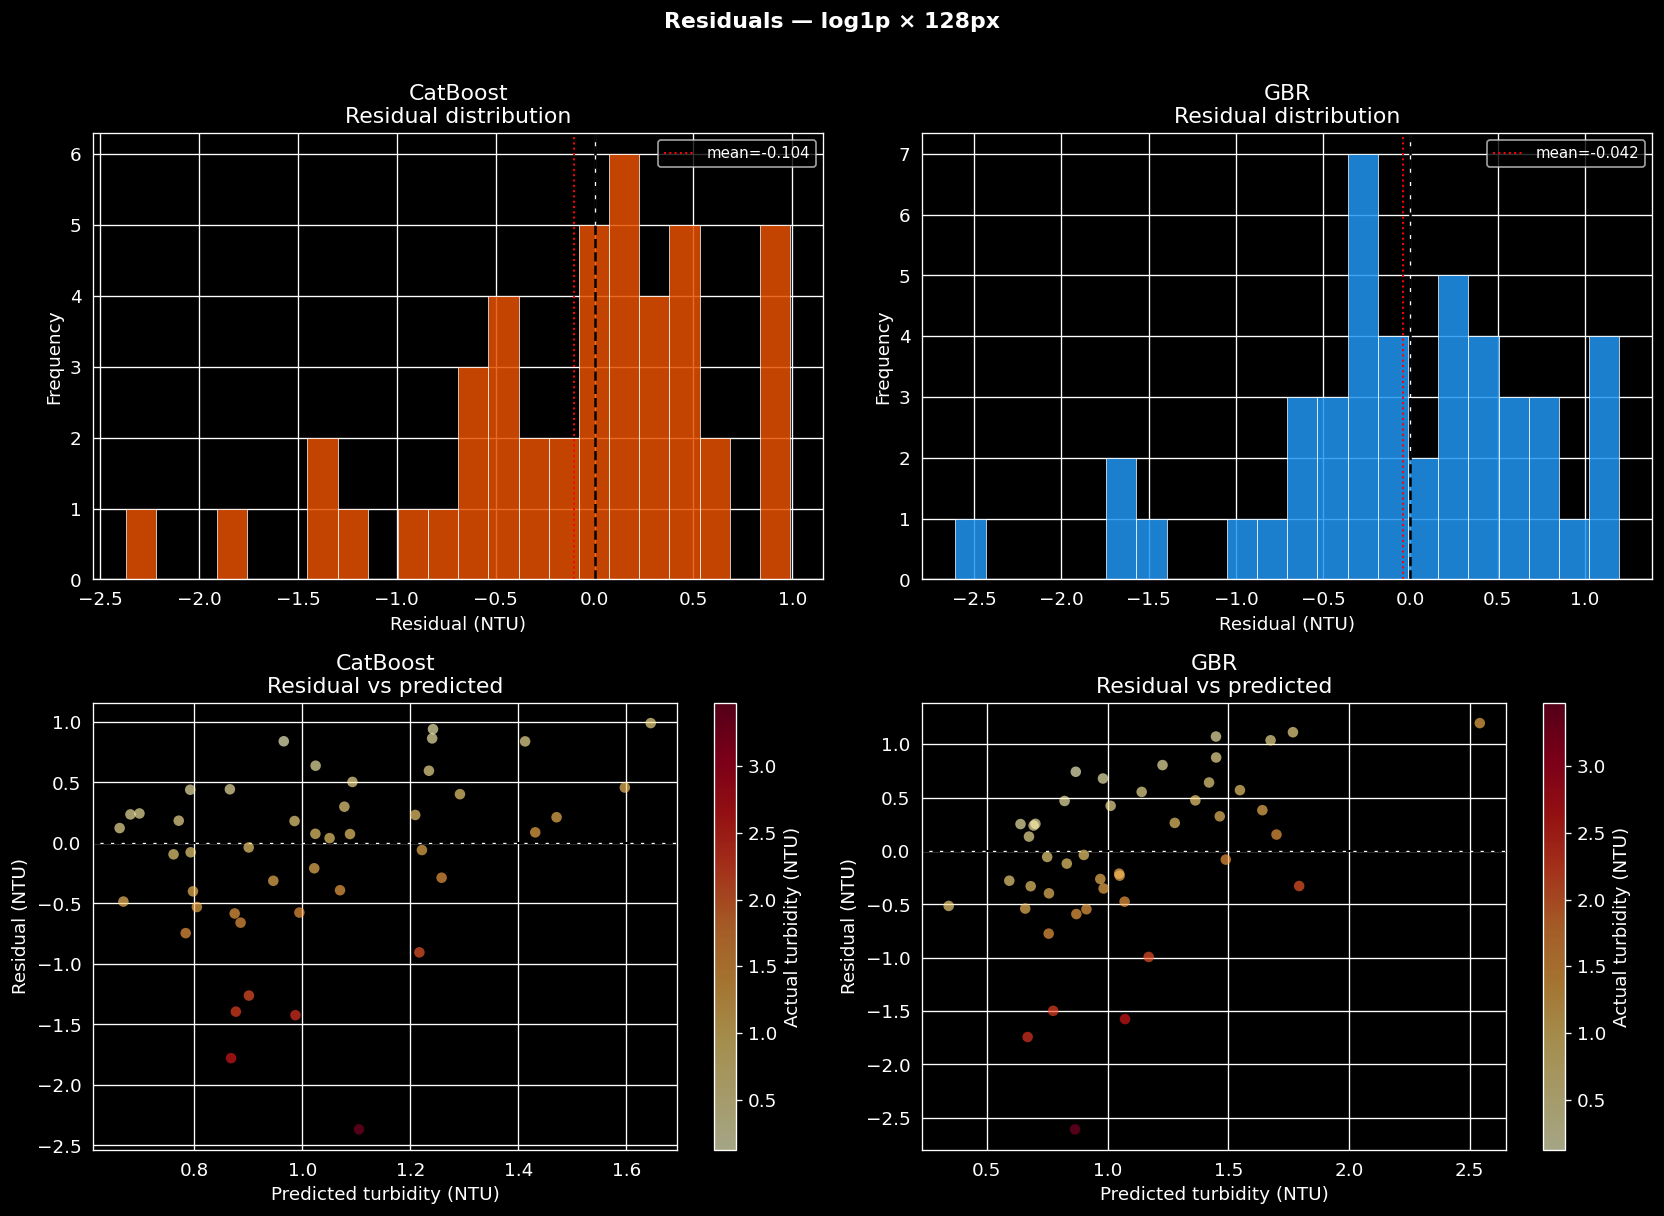

In [12]:
fig, axes = plt.subplots(2, len(available_models), figsize=(7 * len(available_models), 10))
if len(available_models) == 1:
    axes = axes.reshape(2, 1)

for col, mt in enumerate(available_models):
    sub     = test_preds_df[(test_preds_df['dataset']  == best_ds) &
                             (test_preds_df['patch_px'] == best_px) &
                             (test_preds_df['model']    == mt)]
    y_t     = to_ntu(sub['turbidity'].values, best_ds)
    y_p     = to_ntu(sub['pred'].values,      best_ds)
    residual = y_p - y_t
    color   = MODEL_COLORS.get(mt, 'steelblue')

    # Residual histogram
    ax0 = axes[0, col]
    ax0.hist(residual, bins=22, color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax0.axvline(0,              color='black', lw=1.5, linestyle='--')
    ax0.axvline(residual.mean(), color='red',   lw=1.2, linestyle=':',
                label=f'mean={residual.mean():+.3f}')
    ax0.set_xlabel('Residual (NTU)')
    ax0.set_ylabel('Frequency')
    ax0.set_title(f'{mt}\nResidual distribution')
    ax0.legend(fontsize=9)

    # Residuals vs predicted
    ax1 = axes[1, col]
    sc = ax1.scatter(y_p, residual, alpha=0.65, s=40, c=y_t,
                     cmap='YlOrRd', edgecolors='none', zorder=3)
    ax1.axhline(0, color='black', lw=1.2, linestyle='--')
    plt.colorbar(sc, ax=ax1, label='Actual turbidity (NTU)')
    ax1.set_xlabel('Predicted turbidity (NTU)')
    ax1.set_ylabel('Residual (NTU)')
    ax1.set_title(f'{mt}\nResidual vs predicted')

plt.suptitle(f'Residuals — {best_ds} × {best_px}px', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RES_DIR / 'eval_residuals.png', bbox_inches='tight')
plt.show()

## 6. Feature importance

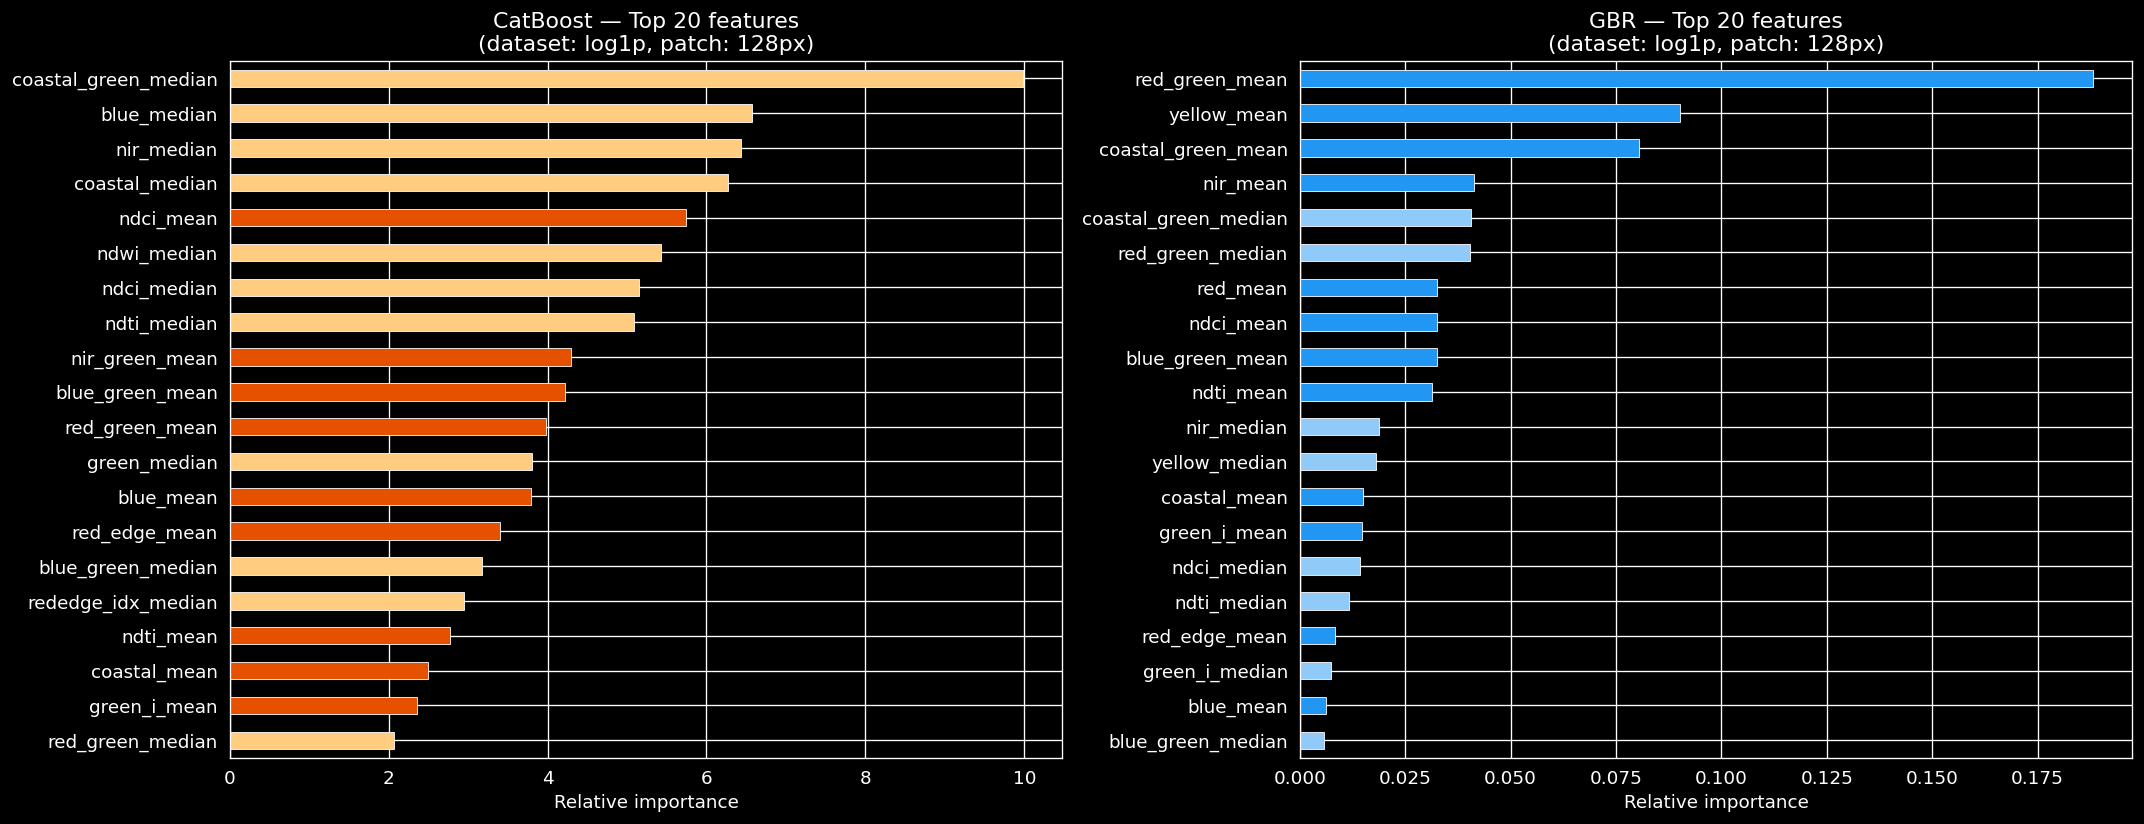

In [13]:
from sklearn.inspection import permutation_importance

top_n = 20
feat_cols_file = f'{best_ds}__{best_px}px__{best_model}__feat_cols.pkl'
feat_cols = pickle.load(open(MOD_DIR / feat_cols_file, 'rb'))

# Load feature data for GBR permutation importance
fe_path = BASE_DIR / 'data' / 'processed' / 'feature_engineering' / f'fe_{best_px}px.parquet'
fe_df   = pd.read_parquet(fe_path)

fig, axes = plt.subplots(1, len(available_models), figsize=(9 * len(available_models), 7))
if len(available_models) == 1:
    axes = [axes]

for ax, mt in zip(axes, available_models):
    model_path = MOD_DIR / f'{best_ds}__{best_px}px__{mt}.pkl'
    if not model_path.exists():
        ax.set_visible(False)
        continue
    model = pickle.load(open(model_path, 'rb'))
    color = MODEL_COLORS.get(mt, 'steelblue')

    if mt == 'GBR':
        # HistGradientBoostingRegressor has no feature_importances_; use permutation importance
        X_fe = fe_df[feat_cols].values
        perm = permutation_importance(model, X_fe, model.predict(X_fe),
                                      n_repeats=8, random_state=42, n_jobs=-1)
        imp = pd.Series(perm.importances_mean, index=feat_cols, name='importance')
    elif mt == 'CatBoost':
        imp = pd.Series(model.get_feature_importance(), index=feat_cols, name='importance')
    else:
        ax.set_visible(False)
        continue

    top = imp.sort_values(ascending=True).tail(top_n)
    colors_bar = [color if 'mean' in f else '#90CAF9' if mt == 'GBR' else '#FFCC80'
                  for f in top.index]
    top.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{mt} — Top {top_n} features\n(dataset: {best_ds}, patch: {best_px}px)')
    ax.set_xlabel('Relative importance')

plt.tight_layout()
plt.savefig(RES_DIR / 'eval_feature_importance.png', bbox_inches='tight')
plt.show()

## 7. Error by CTD station

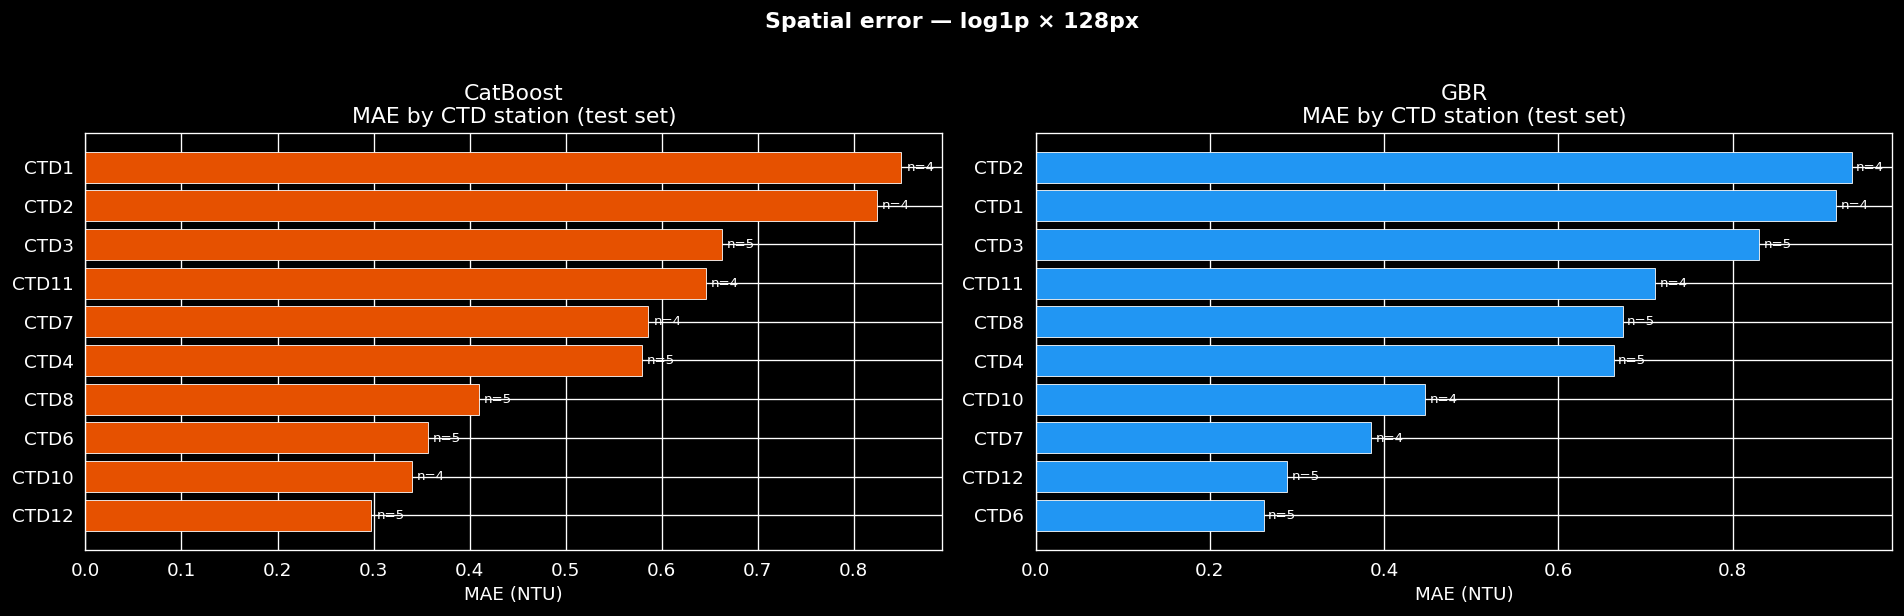

In [14]:
fig, axes = plt.subplots(1, len(available_models), figsize=(8 * len(available_models), 5))
if len(available_models) == 1:
    axes = [axes]

for ax, mt in zip(axes, available_models):
    sub = test_preds_df[(test_preds_df['dataset']  == best_ds) &
                         (test_preds_df['patch_px'] == best_px) &
                         (test_preds_df['model']    == mt)].copy()
    sub['y_true'] = to_ntu(sub['turbidity'].values, best_ds)
    sub['y_pred'] = to_ntu(sub['pred'].values,      best_ds)
    sub['abs_err'] = (sub['y_pred'] - sub['y_true']).abs()
    ctd_err = sub.groupby('ctd').agg(mae=('abs_err', 'mean'),
                                      n=('abs_err', 'count')).sort_values('mae')

    color = MODEL_COLORS.get(mt, 'steelblue')
    bars = ax.barh(ctd_err.index, ctd_err['mae'], color=color,
                   edgecolor='white', linewidth=0.5)
    for bar, n_obs in zip(bars, ctd_err['n']):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'n={n_obs}', va='center', fontsize=8)
    ax.set_xlabel('MAE (NTU)')
    ax.set_title(f'{mt}\nMAE by CTD station (test set)')

plt.suptitle(f'Spatial error — {best_ds} × {best_px}px', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RES_DIR / 'eval_error_by_ctd.png', bbox_inches='tight')
plt.show()

## 8. Error by test date

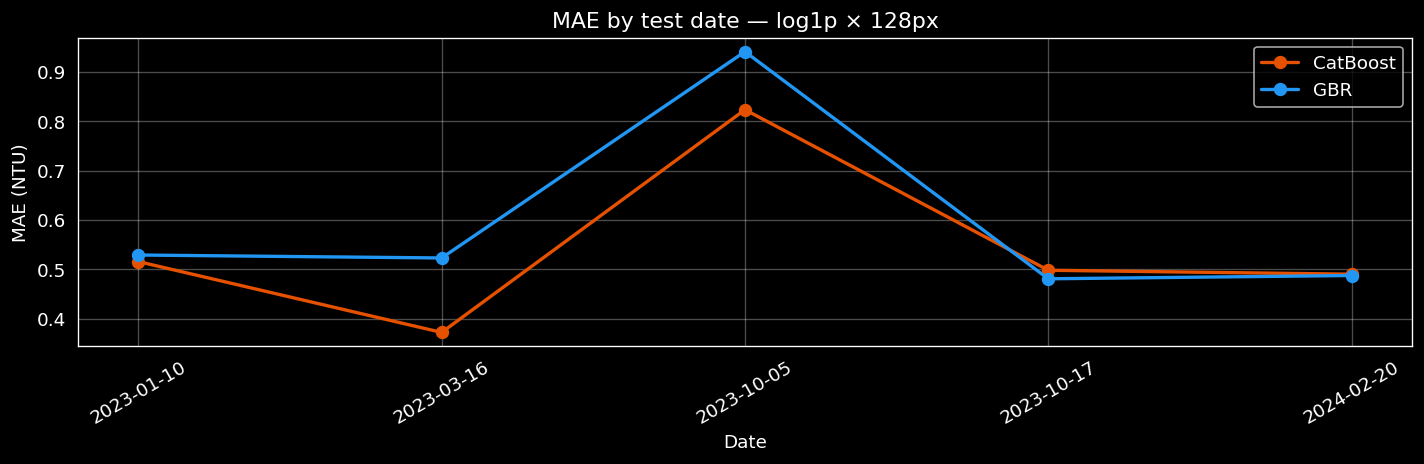

In [15]:
date_rows = []
for (ds, px, mt, dt), grp in test_preds_df.groupby(['dataset', 'patch_px', 'model', 'date']):
    y_t = to_ntu(grp['turbidity'].values, ds)
    y_p = to_ntu(grp['pred'].values,      ds)
    date_rows.append({
        'dataset': ds, 'patch_px': px, 'model': mt, 'date': dt,
        'mae':  mean_absolute_error(y_t, y_p),
        'rmse': np.sqrt(mean_squared_error(y_t, y_p)),
        'n':    len(grp),
    })
date_err = pd.DataFrame(date_rows)

sub_date = date_err[(date_err['dataset'] == best_ds) &
                    (date_err['patch_px'] == best_px)]

fig, ax = plt.subplots(figsize=(12, 4))
for mt in available_models:
    d = sub_date[sub_date['model'] == mt].sort_values('date')
    ax.plot(d['date'].dt.strftime('%Y-%m-%d'), d['mae'],
            'o-', label=mt, color=MODEL_COLORS.get(mt, 'gray'),
            markersize=7, linewidth=2)

ax.set_xlabel('Date')
ax.set_ylabel('MAE (NTU)')
ax.set_title(f'MAE by test date — {best_ds} × {best_px}px')
ax.legend()
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RES_DIR / 'eval_error_by_date.png', bbox_inches='tight')
plt.show()

## 9. Effect of spatial scale (patch size)

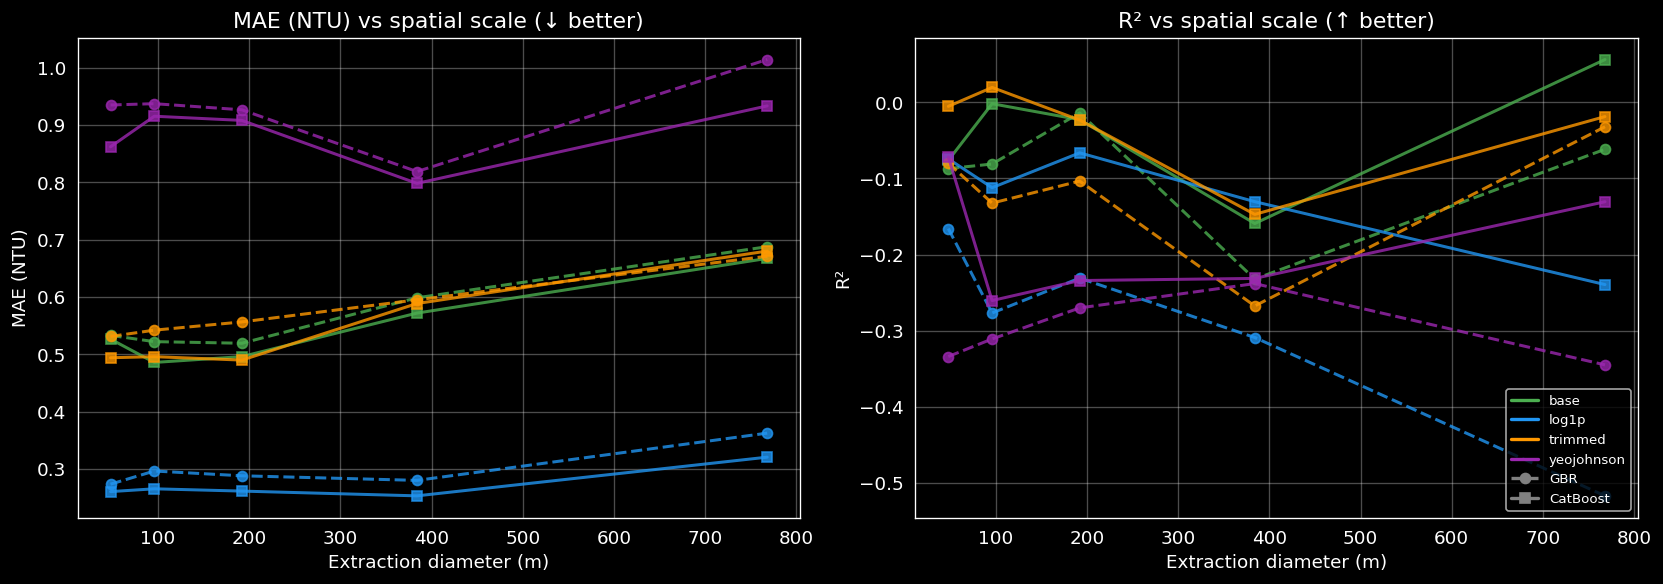

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metric, label, better) in zip(axes, [
    ('test_mae', 'MAE (NTU)', '↓'),
    ('test_r2',  'R²',        '↑'),
]):
    for ds in DS_ORDER:
        for mt in available_models:
            sub = (metrics_df[(metrics_df['dataset'] == ds) &
                               (metrics_df['model']   == mt)]
                   .sort_values('diameter_m'))
            if sub.empty:
                continue
            ls = '--' if mt == 'GBR' else '-'
            color = DS_COLORS.get(ds, 'gray')
            ax.plot(sub['diameter_m'], sub[metric],
                    marker='o' if mt == 'GBR' else 's',
                    linestyle=ls, color=color, alpha=0.8,
                    label=f'{ds}/{mt}', linewidth=1.8, markersize=6)

    ax.set_xlabel('Extraction diameter (m)')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs spatial scale ({better} better)')
    ax.grid(alpha=0.3)

# Compact legend: dataset and model only
from matplotlib.lines import Line2D
handles = ([Line2D([0], [0], color=DS_COLORS[d], lw=2, label=d) for d in DS_ORDER if d in DS_COLORS] +
           [Line2D([0], [0], color='gray', lw=2, ls='--', marker='o', label='GBR'),
            Line2D([0], [0], color='gray', lw=2, ls='-',  marker='s', label='CatBoost')])
axes[1].legend(handles=handles, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(RES_DIR / 'eval_scale_effect.png', bbox_inches='tight')
plt.show()

## 10. Graphical representation of observed and predicted turbidity

Complete visual analysis of turbidity values in NTU:
- Statistical distribution
- Time series by station
- Seasonal patterns
- Observed vs predicted comparison on the test set

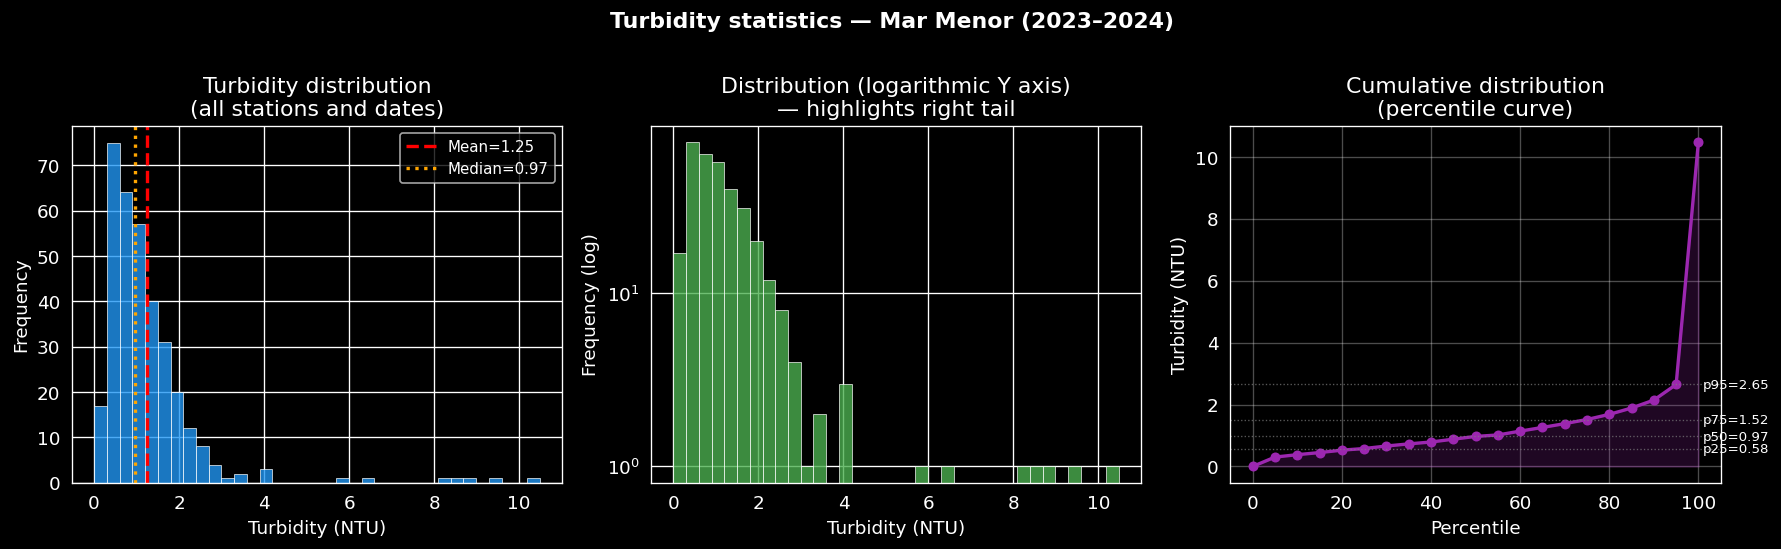

Descriptive statistics (NTU):
count    341.000
mean       1.247
std        1.262
min        0.000
25%        0.579
50%        0.970
75%        1.516
max       10.488


In [17]:
# ── 10.1 Turbidity statistical distribution (full dataset, NTU) ─────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Histogram
ax = axes[0]
ax.hist(base_df['turbidity'], bins=35, color='#2196F3', alpha=0.8,
        edgecolor='white', linewidth=0.5)
ax.axvline(base_df['turbidity'].mean(),   color='red',    lw=2, linestyle='--', label=f'Mean={base_df["turbidity"].mean():.2f}')
ax.axvline(base_df['turbidity'].median(), color='orange', lw=2, linestyle=':',  label=f'Median={base_df["turbidity"].median():.2f}')
ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Frequency')
ax.set_title('Turbidity distribution\n(all stations and dates)')
ax.legend(fontsize=9)

# Histogram with log scale
ax = axes[1]
ax.hist(base_df['turbidity'], bins=35, color='#4CAF50', alpha=0.8,
        edgecolor='white', linewidth=0.5)
ax.set_yscale('log')
ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Frequency (log)')
ax.set_title('Distribution (logarithmic Y axis)\n— highlights right tail')

# Percentiles
ax = axes[2]
percentiles = np.arange(0, 101, 5)
pct_values  = np.percentile(base_df['turbidity'], percentiles)
ax.plot(percentiles, pct_values, 'o-', color='#9C27B0', linewidth=2, markersize=5)
ax.fill_between(percentiles, pct_values, alpha=0.2, color='#9C27B0')
ax.set_xlabel('Percentile')
ax.set_ylabel('Turbidity (NTU)')
ax.set_title('Cumulative distribution\n(percentile curve)')
ax.grid(alpha=0.3)
for pct, val in [(25, np.percentile(base_df['turbidity'], 25)),
                 (50, np.percentile(base_df['turbidity'], 50)),
                 (75, np.percentile(base_df['turbidity'], 75)),
                 (95, np.percentile(base_df['turbidity'], 95))]:
    ax.axhline(val, color='gray', lw=0.8, linestyle=':', alpha=0.7)
    ax.text(101, val, f'p{pct}={val:.2f}', va='center', fontsize=8)

plt.suptitle('Turbidity statistics — Mar Menor (2023–2024)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RES_DIR / 'turb_distribution.png', bbox_inches='tight')
plt.show()

print('Descriptive statistics (NTU):')
print(base_df['turbidity'].describe().round(3).to_string())

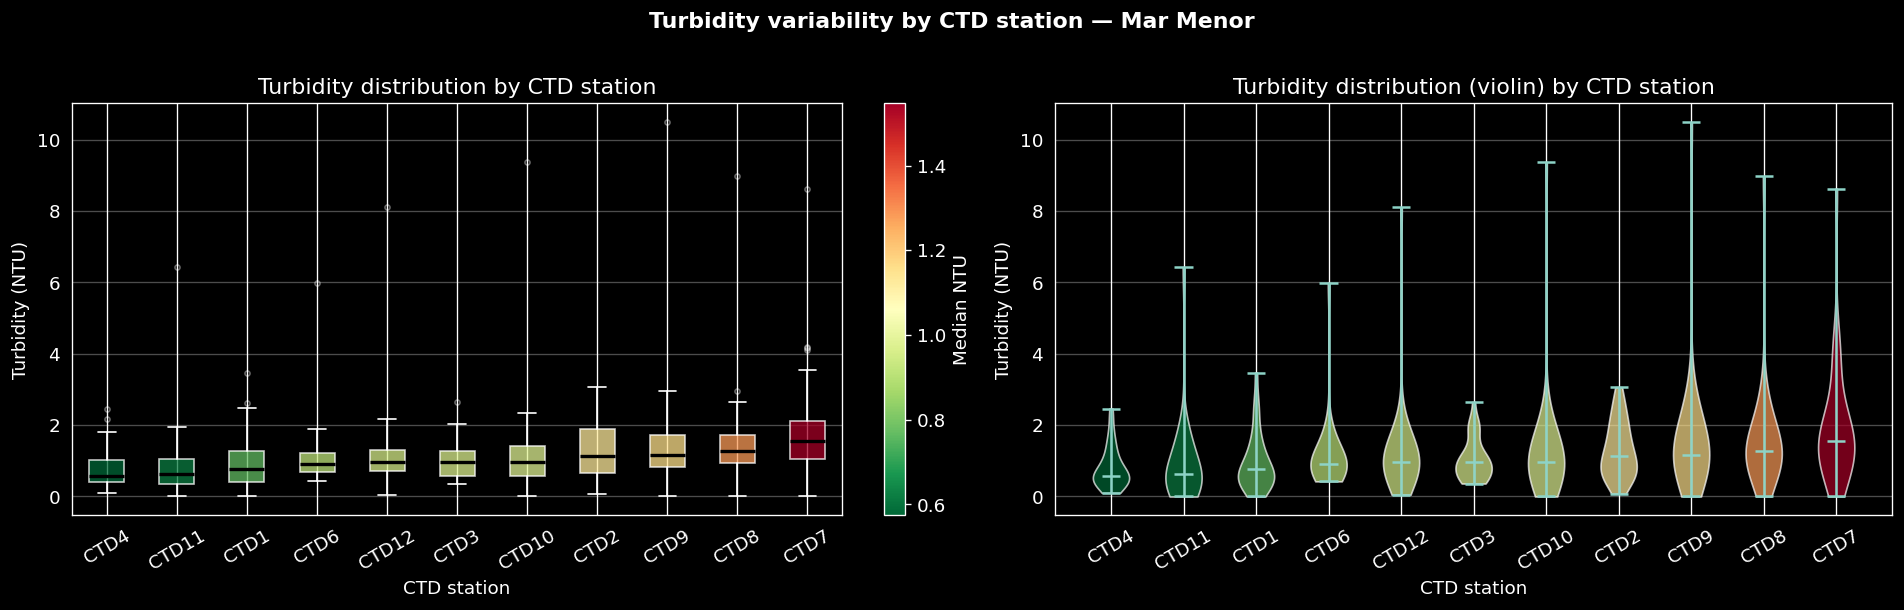

In [18]:
# ── 10.2 Turbidity boxplots by CTD station ─────────────────────────────────
ctd_order = (base_df.groupby('ctd')['turbidity'].median()
             .sort_values().index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot
ax = axes[0]
data_by_ctd = [base_df[base_df['ctd'] == c]['turbidity'].values for c in ctd_order]
bp = ax.boxplot(data_by_ctd, labels=ctd_order, patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', ms=3, alpha=0.4),
                medianprops=dict(color='black', lw=2))
cmap = plt.cm.RdYlGn_r
medians = [np.median(d) for d in data_by_ctd]
norm_med = plt.Normalize(min(medians), max(medians))
for patch, med in zip(bp['boxes'], medians):
    patch.set_facecolor(cmap(norm_med(med)))
    patch.set_alpha(0.75)
ax.set_xlabel('CTD station')
ax.set_ylabel('Turbidity (NTU)')
ax.set_title('Turbidity distribution by CTD station')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_med)
plt.colorbar(sm, ax=ax, label='Median NTU', fraction=0.03)

# Violin
ax = axes[1]
vp = ax.violinplot(data_by_ctd, positions=range(len(ctd_order)),
                    showmedians=True, showextrema=True)
for pc, med in zip(vp['bodies'], medians):
    pc.set_facecolor(cmap(norm_med(med)))
    pc.set_alpha(0.7)
ax.set_xticks(range(len(ctd_order)))
ax.set_xticklabels(ctd_order, rotation=30)
ax.set_xlabel('CTD station')
ax.set_ylabel('Turbidity (NTU)')
ax.set_title('Turbidity distribution (violin) by CTD station')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Turbidity variability by CTD station — Mar Menor', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RES_DIR / 'turb_by_ctd.png', bbox_inches='tight')
plt.show()

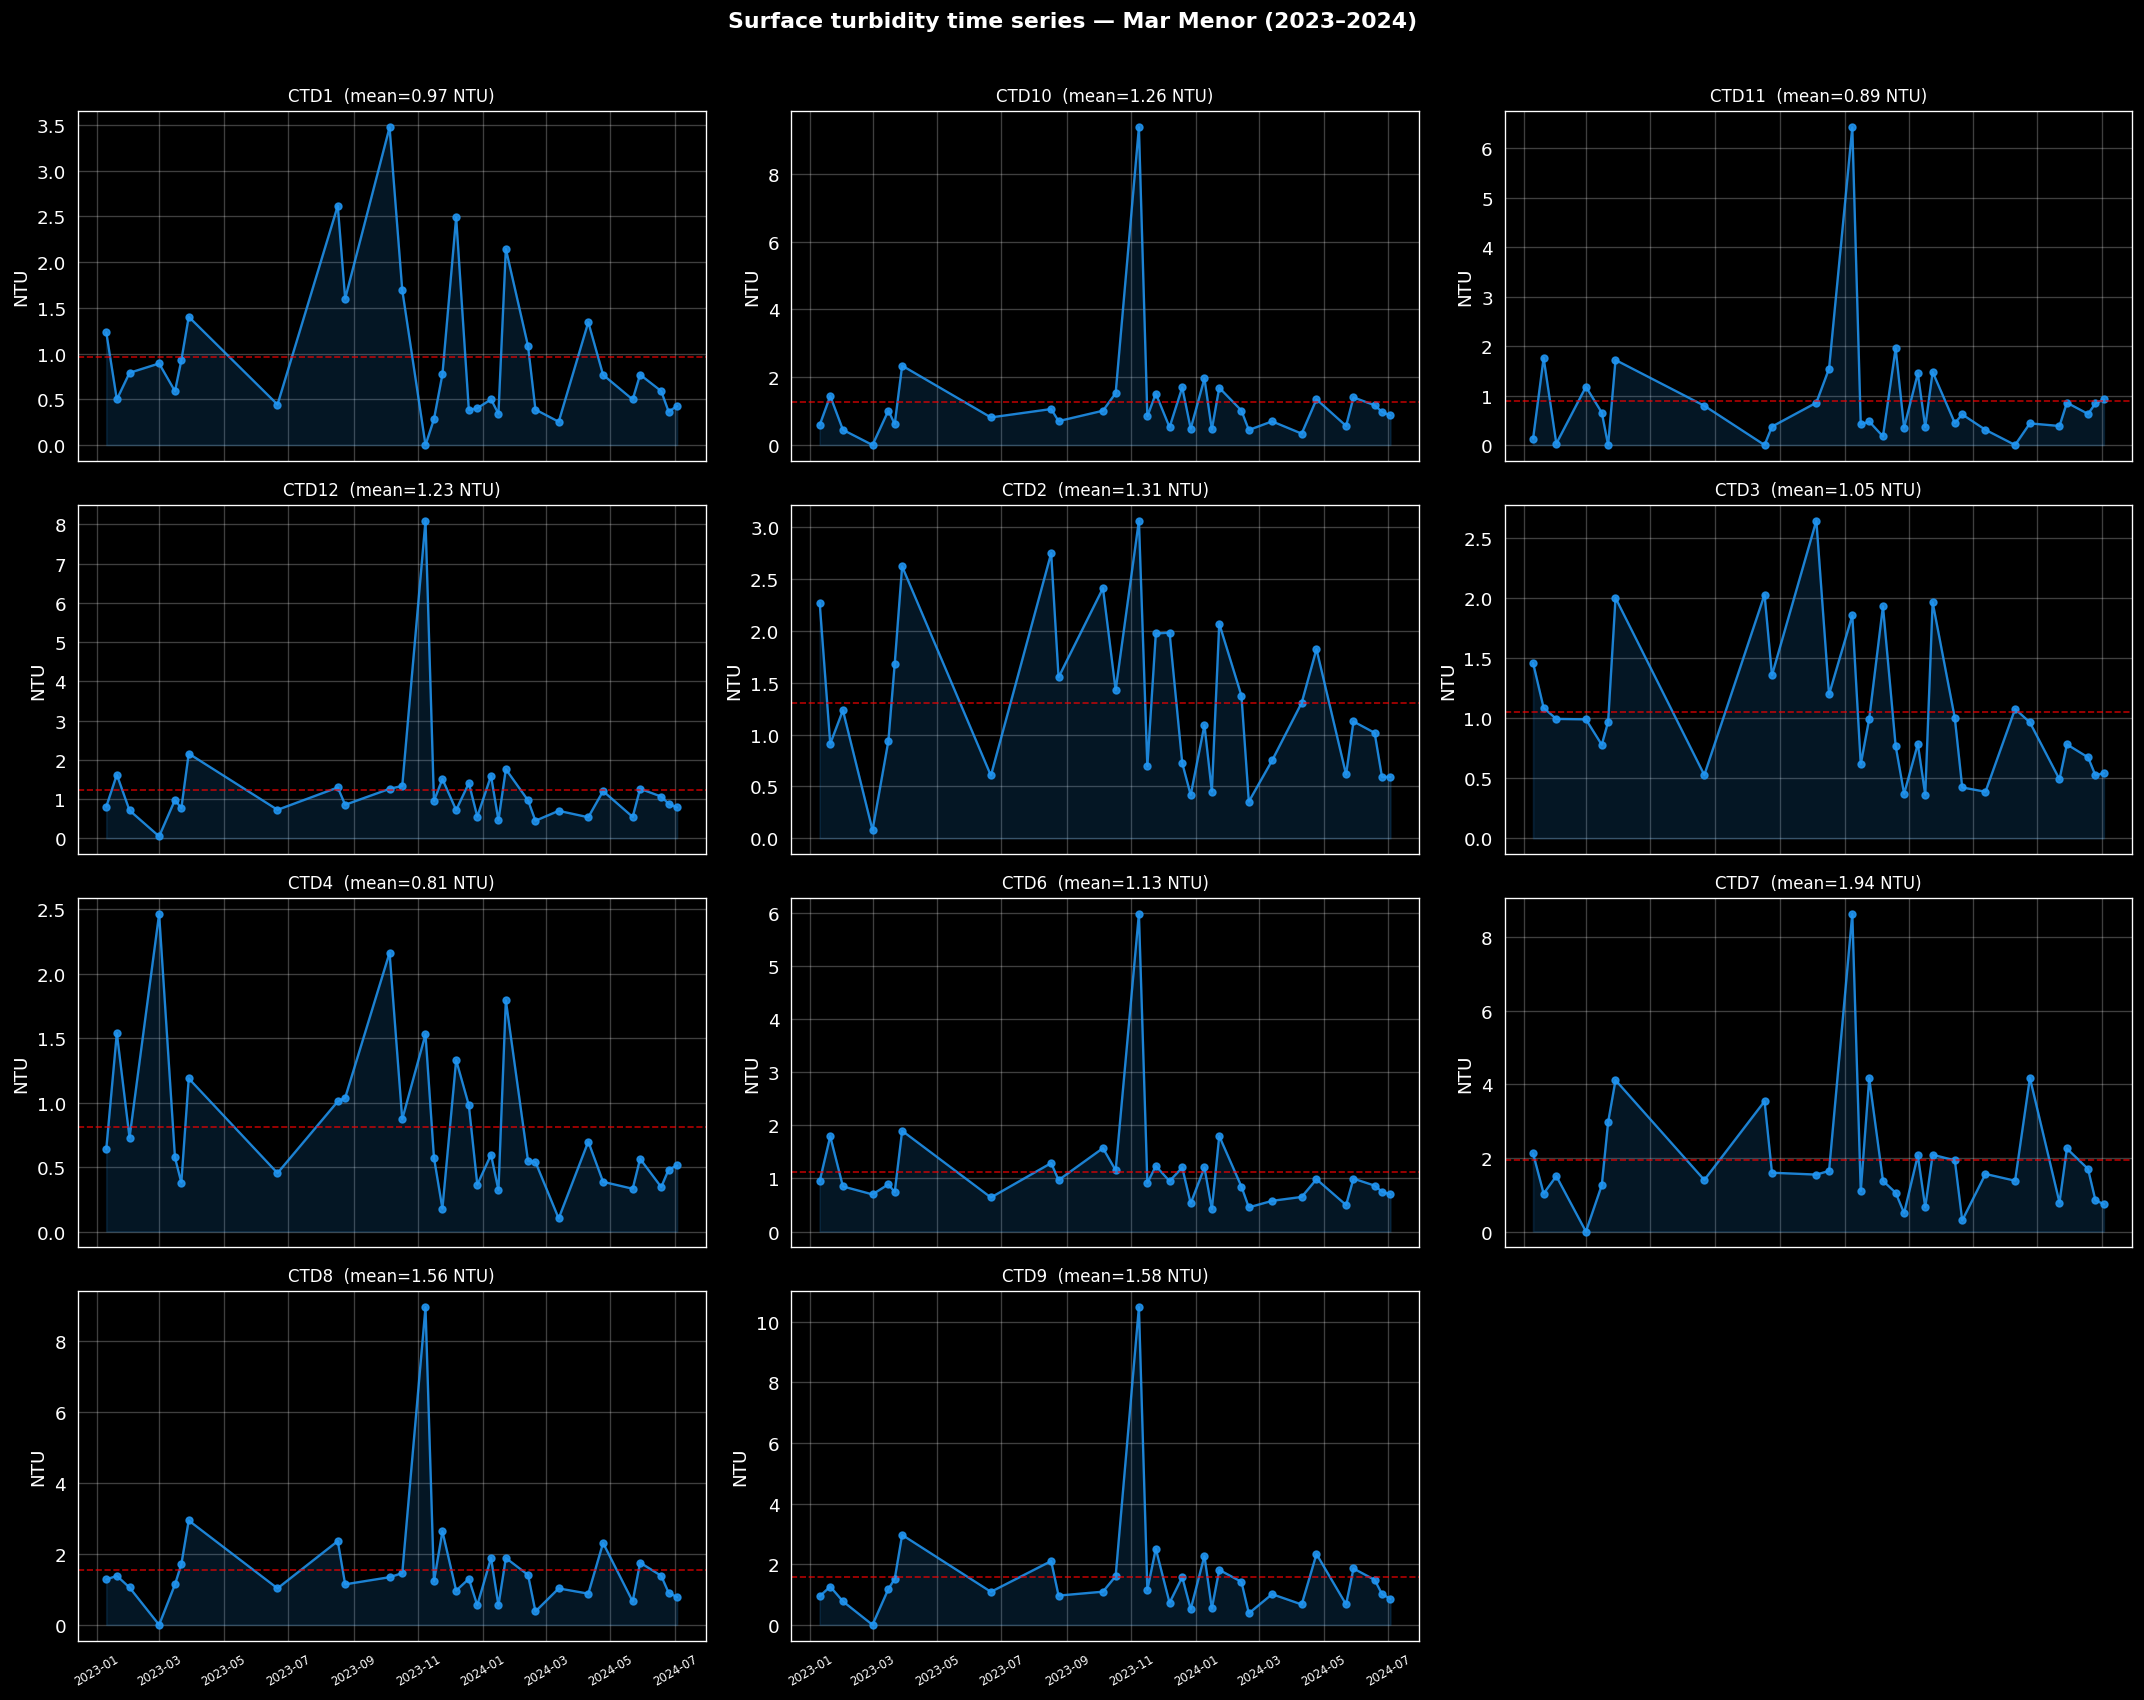

In [19]:
# ── 10.3 Turbidity time series by station ────────────────────────────
base_df_parsed = base_df.copy()
base_df_parsed['date'] = pd.to_datetime(base_df_parsed['date'])

ctds_sorted = sorted(base_df_parsed['ctd'].unique())
ncols = 3
nrows = int(np.ceil(len(ctds_sorted) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows), sharex=True)
axes_flat = axes.flatten()

for ax, ctd in zip(axes_flat, ctds_sorted):
    d = base_df_parsed[base_df_parsed['ctd'] == ctd].sort_values('date')
    ax.plot(d['date'], d['turbidity'], 'o-', color='#2196F3',
            markersize=4, linewidth=1.4, alpha=0.85)
    ax.fill_between(d['date'], d['turbidity'], alpha=0.15, color='#2196F3')
    ax.axhline(d['turbidity'].mean(), color='red', lw=1, linestyle='--', alpha=0.7)
    ax.set_title(f'{ctd}  (mean={d["turbidity"].mean():.2f} NTU)', fontsize=10)
    ax.set_ylabel('NTU')
    ax.grid(alpha=0.25)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

for ax in axes_flat[len(ctds_sorted):]:
    ax.set_visible(False)

plt.suptitle('Surface turbidity time series — Mar Menor (2023–2024)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RES_DIR / 'turb_timeseries.png', bbox_inches='tight')
plt.show()

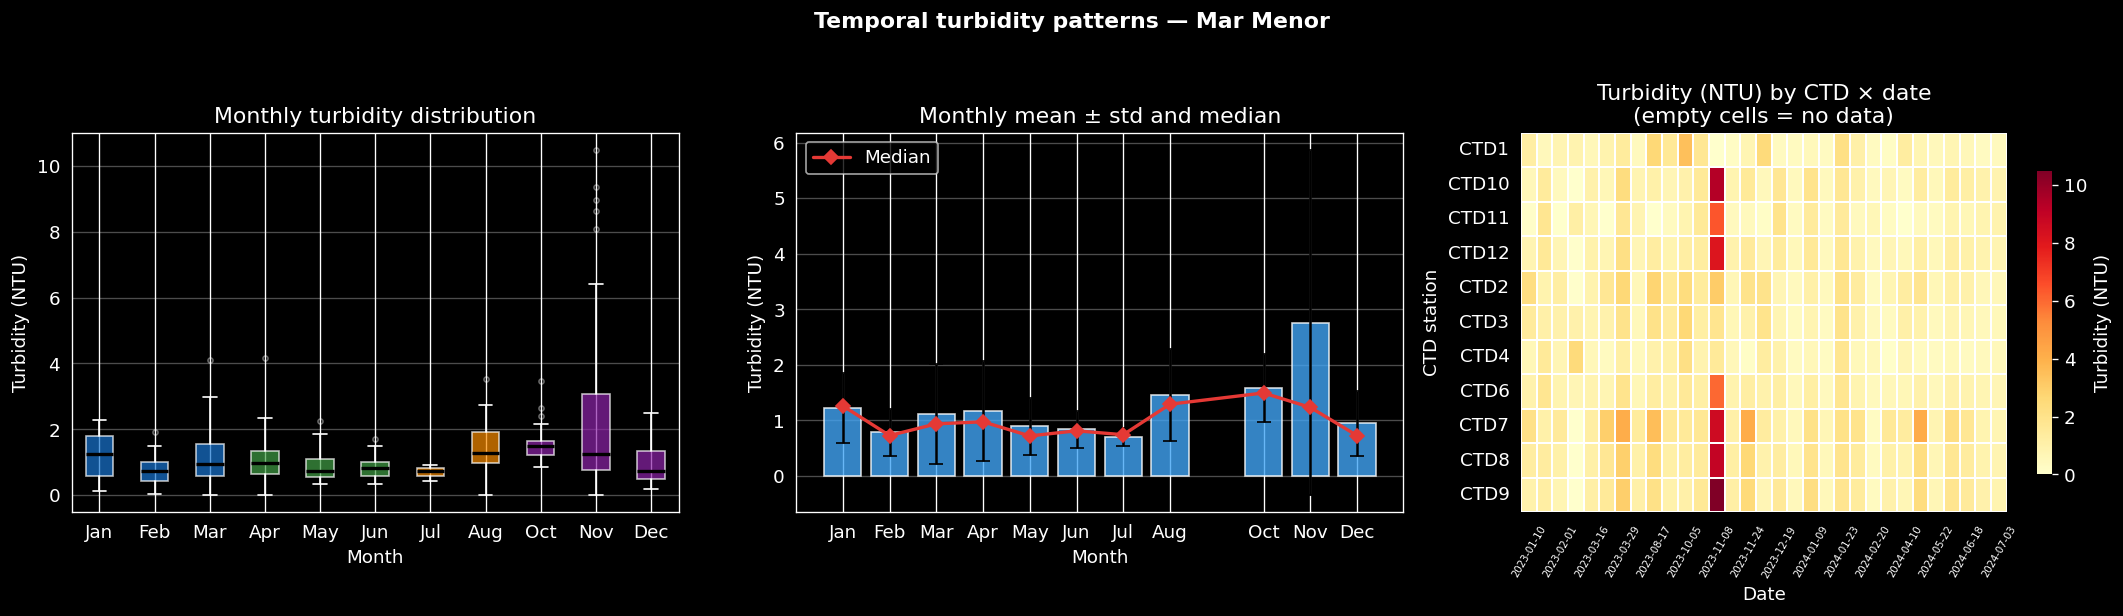

In [20]:
# ── 10.4 Monthly and seasonal patterns ─────────────────────────────────────
base_df_parsed['month']  = base_df_parsed['date'].dt.month
base_df_parsed['season'] = base_df_parsed['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
     3: 'Spring', 4: 'Spring', 5: 'Spring',
     6: 'Summer',    7: 'Summer',    8: 'Summer',
     9: 'Autumn',    10: 'Autumn',   11: 'Autumn',
})
MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Monthly boxplot
ax = axes[0]
months_present = sorted(base_df_parsed['month'].unique())
monthly_data   = [base_df_parsed[base_df_parsed['month'] == m]['turbidity'].values
                  for m in months_present]
monthly_labels = [MONTH_NAMES[m - 1] for m in months_present]
monthly_colors = ['#1976D2'] * 3 + ['#43A047'] * 3 + ['#FB8C00'] * 3 + ['#8E24AA'] * 3
monthly_colors = [monthly_colors[(m - 1) // 3 * 3] for m in months_present]

bp = ax.boxplot(monthly_data, labels=monthly_labels, patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', ms=3, alpha=0.4),
                medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], monthly_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_xlabel('Month')
ax.set_ylabel('Turbidity (NTU)')
ax.set_title('Monthly turbidity distribution')
ax.grid(axis='y', alpha=0.3)

# Monthly mean + std
ax = axes[1]
monthly_stats = base_df_parsed.groupby('month')['turbidity'].agg(['mean', 'std', 'median'])
ax.bar(monthly_stats.index, monthly_stats['mean'],
       yerr=monthly_stats['std'], capsize=4,
       color='#42A5F5', alpha=0.8, edgecolor='white', error_kw={'lw': 1.5})
ax.plot(monthly_stats.index, monthly_stats['median'],
        'D-', color='#E53935', lw=2, ms=6, label='Median')
ax.set_xticks(months_present)
ax.set_xticklabels(monthly_labels)
ax.set_xlabel('Month')
ax.set_ylabel('Turbidity (NTU)')
ax.set_title('Monthly mean ± std and median')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Heatmap: mean turbidity by CTD × date
ax = axes[2]
pivot_turb = base_df_parsed.pivot_table(
    index='ctd', columns='date', values='turbidity', aggfunc='mean'
)
pivot_turb.columns = [str(c.date()) for c in pivot_turb.columns]
pivot_turb = pivot_turb.reindex(ctds_sorted)

sns.heatmap(pivot_turb, ax=ax, cmap='YlOrRd', linewidths=0.1,
            cbar_kws={'label': 'Turbidity (NTU)', 'shrink': 0.8})
ax.set_title('Turbidity (NTU) by CTD × date\n(empty cells = no data)')
ax.set_xlabel('Date')
ax.set_ylabel('CTD station')
ax.tick_params(axis='x', rotation=60, labelsize=6)

plt.suptitle('Temporal turbidity patterns — Mar Menor', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RES_DIR / 'turb_seasonal.png', bbox_inches='tight')
plt.show()

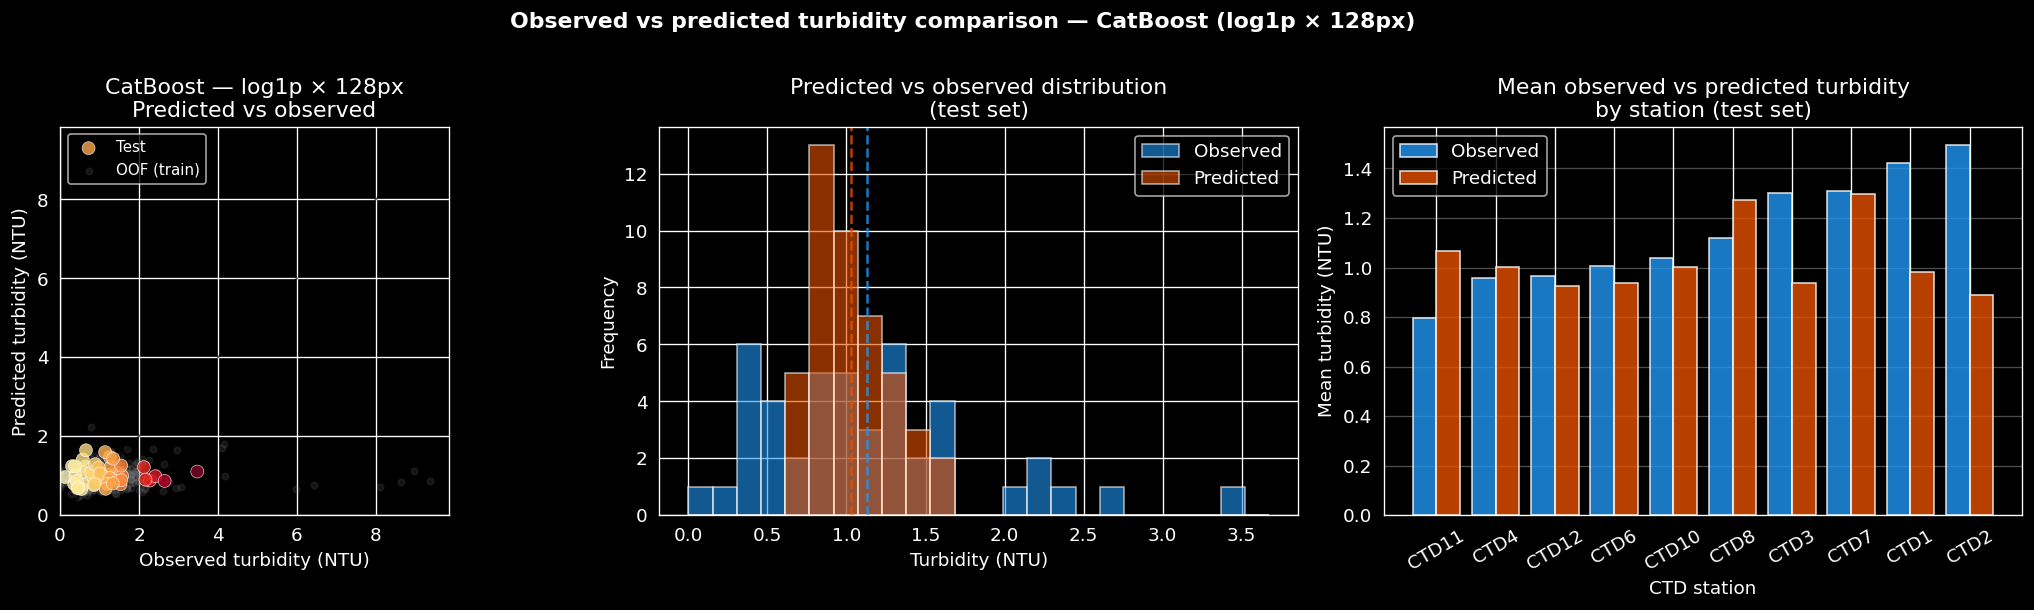

In [21]:
# ── 10.5 Predicted vs observed comparison on the test set (best model) ───
# Includes train (OOF) + test to see the full range

best_test = test_preds_df[(test_preds_df['dataset']  == best_ds) &
                           (test_preds_df['patch_px'] == best_px) &
                           (test_preds_df['model']    == best_model)].copy()
best_oof  = oof_preds_df[ (oof_preds_df['dataset']   == best_ds) &
                           (oof_preds_df['patch_px']  == best_px) &
                           (oof_preds_df['model']     == best_model)].copy()

best_test['y_true'] = to_ntu(best_test['turbidity'].values, best_ds)
best_test['y_pred'] = to_ntu(best_test['pred'].values,      best_ds)
best_oof[ 'y_true'] = to_ntu(best_oof['turbidity'].values,  best_ds)
best_oof[ 'y_pred'] = to_ntu(best_oof['pred'].values,       best_ds)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Predicted vs observed (test) with marginal distribution
ax = axes[0]
ax.scatter(best_test['y_true'], best_test['y_pred'],
           c=best_test['y_true'], cmap='YlOrRd', vmin=0, vmax=3,
           s=60, alpha=0.8, edgecolors='white', linewidth=0.4, zorder=3, label='Test')
ax.scatter(best_oof['y_true'], best_oof['y_pred'],
           alpha=0.15, s=15, color='gray', zorder=1, label='OOF (train)')
lim = max(best_test['y_true'].max(), best_test['y_pred'].max(),
          best_oof['y_true'].max(), best_oof['y_pred'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=1.2, alpha=0.6)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('Observed turbidity (NTU)')
ax.set_ylabel('Predicted turbidity (NTU)')
ax.set_title(f'{best_model} — {best_ds} × {best_px}px\nPredicted vs observed')
ax.legend(fontsize=9)
ax.set_aspect('equal')

# Panel 2: Observed vs predicted distributions (test)
ax = axes[1]
bins = np.linspace(0, max(best_test['y_true'].max(), best_test['y_pred'].max()) + 0.2, 25)
ax.hist(best_test['y_true'], bins=bins, alpha=0.6, color='#2196F3',
        label='Observed', edgecolor='white')
ax.hist(best_test['y_pred'], bins=bins, alpha=0.6, color='#E65100',
        label='Predicted', edgecolor='white')
ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Frequency')
ax.set_title('Predicted vs observed distribution\n(test set)')
ax.legend()
ax.axvline(best_test['y_true'].mean(), color='#2196F3', lw=1.5, linestyle='--', alpha=0.8)
ax.axvline(best_test['y_pred'].mean(), color='#E65100', lw=1.5, linestyle='--', alpha=0.8)

# Panel 3: Mean turbidity by CTD station (test)
ax = axes[2]
mean_obs_ctd  = best_test.groupby('ctd')['y_true'].mean().sort_values()
mean_pred_ctd = best_test.groupby('ctd')['y_pred'].mean().reindex(mean_obs_ctd.index)

x_pos = np.arange(len(mean_obs_ctd))
ax.bar(x_pos - 0.2, mean_obs_ctd.values,  width=0.4, label='Observed',  color='#2196F3', alpha=0.8)
ax.bar(x_pos + 0.2, mean_pred_ctd.values, width=0.4, label='Predicted', color='#E65100', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(mean_obs_ctd.index, rotation=30)
ax.set_xlabel('CTD station')
ax.set_ylabel('Mean turbidity (NTU)')
ax.set_title('Mean observed vs predicted turbidity\nby station (test set)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Observed vs predicted turbidity comparison — {best_model} ({best_ds} × {best_px}px)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RES_DIR / 'turb_pred_vs_obs.png', bbox_inches='tight')
plt.show()

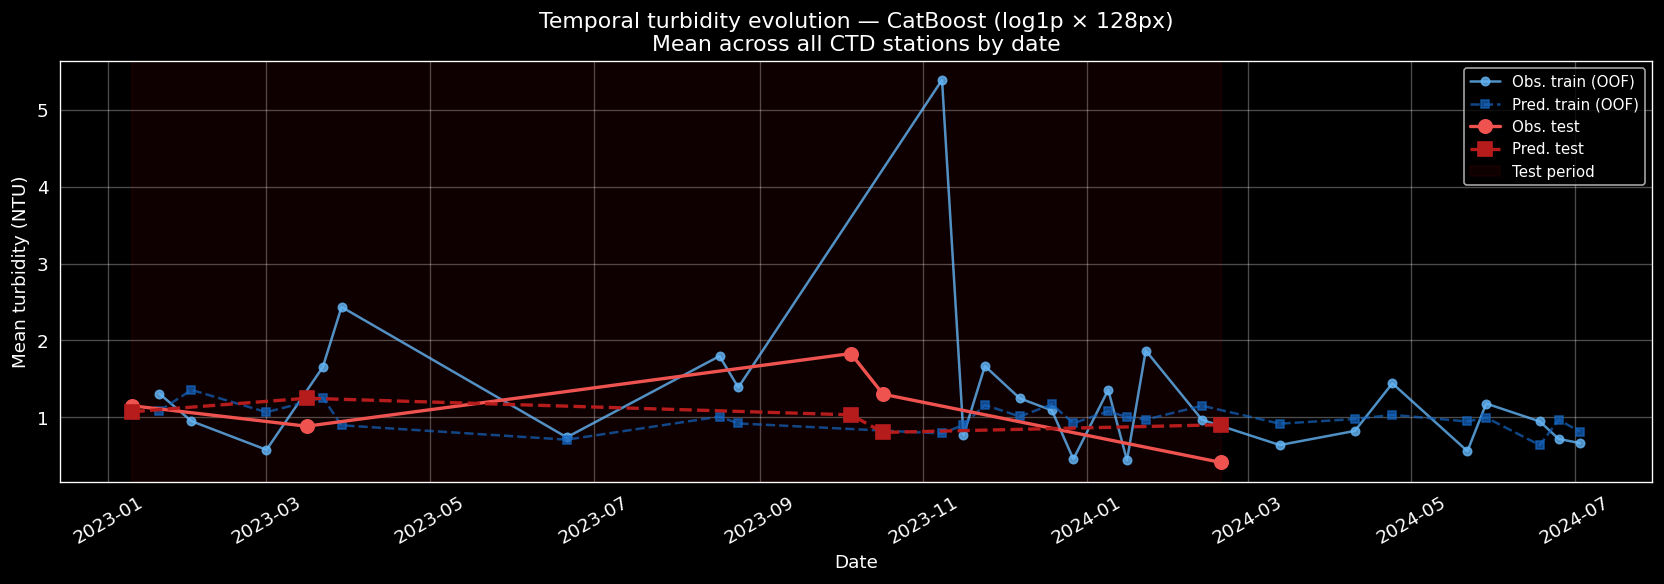

In [22]:
# ── 10.6 Temporal evolution: mean observed vs predicted turbidity ───────────
def date_means(df, label):
    return (df.groupby('date')['y_true'].mean().rename(f'{label}_obs'),
            df.groupby('date')['y_pred'].mean().rename(f'{label}_pred'))

test_obs,  test_pred  = date_means(best_test, 'test')
oof_obs,   oof_pred   = date_means(best_oof,  'oof')

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(oof_obs.index,  oof_obs.values,   'o-', color='#64B5F6', lw=1.5, ms=5,  alpha=0.8, label='Obs. train (OOF)')
ax.plot(oof_pred.index, oof_pred.values,  's--', color='#1565C0', lw=1.5, ms=5, alpha=0.7, label='Pred. train (OOF)')
ax.plot(test_obs.index,  test_obs.values,  'o-', color='#EF5350', lw=2,   ms=8,  zorder=5,  label='Obs. test')
ax.plot(test_pred.index, test_pred.values, 's--', color='#B71C1C', lw=2,   ms=8,  zorder=5,  label='Pred. test')

# Shade test period
if len(test_obs) > 0:
    tmin, tmax = test_obs.index.min(), test_obs.index.max()
    ax.axvspan(tmin, tmax, alpha=0.06, color='red', label='Test period')

ax.set_xlabel('Date')
ax.set_ylabel('Mean turbidity (NTU)')
ax.set_title(f'Temporal turbidity evolution — {best_model} ({best_ds} × {best_px}px)\nMean across all CTD stations by date')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(RES_DIR / 'turb_temporal_evolution.png', bbox_inches='tight')
plt.show()

## 11. Executive summary

In [23]:
best_row = metrics_df.loc[metrics_df['test_mae'].idxmin()]

print('═' * 65)
print('  EVALUATION SUMMARY — Mar Menor Turbidity Model')
print('═' * 65)
print(f'  Dataset              : {best_row["dataset"]}')
print(f'  Patch size           : {int(best_row["patch_px"])} px ({int(best_row["diameter_m"])} m diameter)')
print(f'  Model                : {best_row["model"]}')
print(f'  Final iterations     : {int(best_row["n_iters"])}')
print()
print('  TEST SET Metrics (transformed scale):')
print(f'    MAE       = {best_row["test_mae"]:.4f}  |  RMSE = {best_row["test_rmse"]:.4f}')
print(f'    R²        = {best_row["test_r2"]:.4f}  |  Pearson r = {best_row["test_pearson_r"]:.4f}')
print(f'    Bias      = {best_row["test_bias"]:+.4f}')
print()
print(f'  CV (GroupKFold k=5, groups by date):')
print(f'    CV_MAE    = {best_row["cv_mae"]:.4f} ± {best_row["cv_mae_std"]:.4f}')
print(f'    Gap CV→Test = {best_row["gap_pct"]:+.1f}%')
print()
print('  TEST SET Metrics (original NTU scale):')
sub = test_preds_df[(test_preds_df['dataset']  == best_ds) &
                    (test_preds_df['patch_px']  == best_px) &
                    (test_preds_df['model']     == best_model)]
y_t_ntu = to_ntu(sub['turbidity'].values, best_ds)
y_p_ntu = to_ntu(sub['pred'].values,      best_ds)
print(f'    MAE       = {mean_absolute_error(y_t_ntu, y_p_ntu):.4f} NTU')
print(f'    RMSE      = {np.sqrt(mean_squared_error(y_t_ntu, y_p_ntu)):.4f} NTU')
print(f'    R²        = {r2_score(y_t_ntu, y_p_ntu):.4f}')
print(f'    Pearson r = {pearsonr(y_t_ntu, y_p_ntu)[0]:.4f}')
print()
print('  Observed turbidity (full dataset, NTU):')
print(f'    Mean   = {base_df["turbidity"].mean():.3f}  |  Median = {base_df["turbidity"].median():.3f}')
print(f'    Range  = [{base_df["turbidity"].min():.3f}, {base_df["turbidity"].max():.3f}]')
print()
print('═' * 65)
print()
print('Files generated in results/:')
for fname in ['eval_heatmap_GBR.png',   'eval_heatmap_CatBoost.png',
              'eval_overfit_GBR.png',    'eval_overfit_CatBoost.png',
              'eval_gap_GBR.png',        'eval_gap_CatBoost.png',
              'eval_scatter_best.png',   'eval_scatter_best_per_ds.png',
              'eval_residuals.png',      'eval_feature_importance.png',
              'eval_error_by_ctd.png',   'eval_error_by_date.png',
              'eval_scale_effect.png',
              'turb_distribution.png',   'turb_by_ctd.png',
              'turb_timeseries.png',     'turb_seasonal.png',
              'turb_pred_vs_obs.png',    'turb_temporal_evolution.png']:
    exists = '✓' if (RES_DIR / fname).exists() else '✗'
    print(f'  {exists} {fname}')

═════════════════════════════════════════════════════════════════
  EVALUATION SUMMARY — Mar Menor Turbidity Model
═════════════════════════════════════════════════════════════════
  Dataset              : log1p
  Patch size           : 128 px (384 m diameter)
  Model                : CatBoost
  Final iterations     : 11

  TEST SET Metrics (transformed scale):
    MAE       = 0.2531  |  RMSE = 0.3163
    R²        = -0.1305  |  Pearson r = 0.0326
    Bias      = -0.0110

  CV (GroupKFold k=5, groups by date):
    CV_MAE    = 0.2793 ± 0.0716
    Gap CV→Test = -9.4%

  TEST SET Metrics (original NTU scale):
    MAE       = 0.5447 NTU
    RMSE      = 0.7317 NTU
    R²        = -0.1495
    Pearson r = 0.0009

  Observed turbidity (full dataset, NTU):
    Mean   = 1.247  |  Median = 0.970
    Range  = [0.000, 10.488]

═════════════════════════════════════════════════════════════════

Files generated in results/:
  ✓ eval_heatmap_GBR.png
  ✓ eval_heatmap_CatBoost.png
  ✓ eval_overfit_GBR.pn